# Lab 072 · SCARF / SubTab: learning from different views

**Skill:** build two kinds of tabular views and test the frozen representations. Three TODOs feed the real experiment. PROVIDED shows the entire model and trainer; CHECK tests mechanisms; EXIT requires both measurements and an explanation.

[Lesson](../lessons/0072-scarf-subtab-contrastive-views.html) · [Contract](../labs/l072-reproduction.md)

**Environment:** course Python environment, PyTorch CPU, sklearn, SciPy, NumPy, pandas, matplotlib. Run locally from labs/. Offline real data ships with sklearn. Full run: three datasets × three seeds × six arms, with 40 pretraining epochs. This is a local numeric mechanism experiment, not original-paper table reproduction.

**Cold retrieval:** write VIME’s two targets and explain why unlabeled test features are not free training data. Predict whether useful row recognition guarantees useful class prediction.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

## Start with the question VIME leaves open

In [Lesson 71](../lessons/0071-vime-masked-tabular-ssl.html), an encoder learned from unlabeled rows by repairing corrupted values and detecting changes. An **encoder** is a function that turns an input row into a vector of learned features. Repairing an input gives that function a training signal even when the target label is unavailable. But accurate repair and useful classification are different goals: a model can spend its capacity reconstructing large, predictable nuisance variables.

This lesson asks a different question: **what if the training signal asked the encoder to recognize a row across two incomplete or corrupted observations?** SCARF makes a second observation by replacing values. SubTab makes several observations by selecting different columns. Their choices determine what information the representation is encouraged to preserve.

The connection to the mission is concrete. Before making an entity representation invariant to missing columns, dropped relations, or sampled neighbors, we need to decide which changes preserve the prediction target. Tabular views give us a small, inspectable place to learn that discipline. A useful augmentation for one task can erase the signal for another.

**Your outcome:** trace both training-to-prediction paths, implement three operations used by the running models, and defend a frozen linear-probe result. Suggested pacing: 10 minutes cold retrieval, 35 minutes paper mechanisms, a separate 45–60 minute lab. You may need longer for the experiment and interpretation.



Before reading on, answer from memory: what are VIME’s two targets? Can replacing a value leave it unchanged? Why must unlabeled test rows stay outside an inductive pretraining pool? Write your answers before opening the check.

<details><summary>Check the bridge from Lesson 71</summary><p>VIME trains reconstruction and mask estimation; the implementation studied in L071 targets actual changes, so donor collisions matter. Unlabeled test features still reveal the test distribution. Using them changes the experiment to a transductive one. This lesson uses an inductive boundary: training rows alone define preprocessing, donors and pretraining.</p></details>

<!-- depth-walkthrough:start -->
<div class="learning-route"><p class="route-kicker">THE BIG PICTURE · LESSON 072</p><p><strong>Build on what you know.</strong> VIME in <a href="https://avistian.github.io/relational/lessons/0071-vime-masked-tabular-ssl.html">Lesson 71</a> made the original feature values a target. SCARF and SubTab ask what should stay stable across views; this revisits SAINT in <a href="https://avistian.github.io/relational/lessons/0047-saint.html">Lesson 47</a> at the level of the actual positive pairs and loss denominator.</p><p><strong>The next question.</strong> <a href="https://avistian.github.io/relational/lessons/0073-when-ssl-helps.html">Lesson 73</a> holds these mechanisms fixed and asks when their extra training buys label efficiency. An attractive representation objective is the hypothesis to test, not the result.</p><p><a href="https://avistian.github.io/relational/reference/0071-0090-model-map.html">Open the SSL → relational → graph model map</a> · Work the cold retrieval first, then spend 15–20 minutes tracing this overview before the detailed mechanism and lab.</p></div>



## Two kinds of partial observation

<figure class="model-map"><div class="model-map-scroll" tabindex="0" role="region" aria-label="Architecture diagram; scroll horizontally on narrow screens">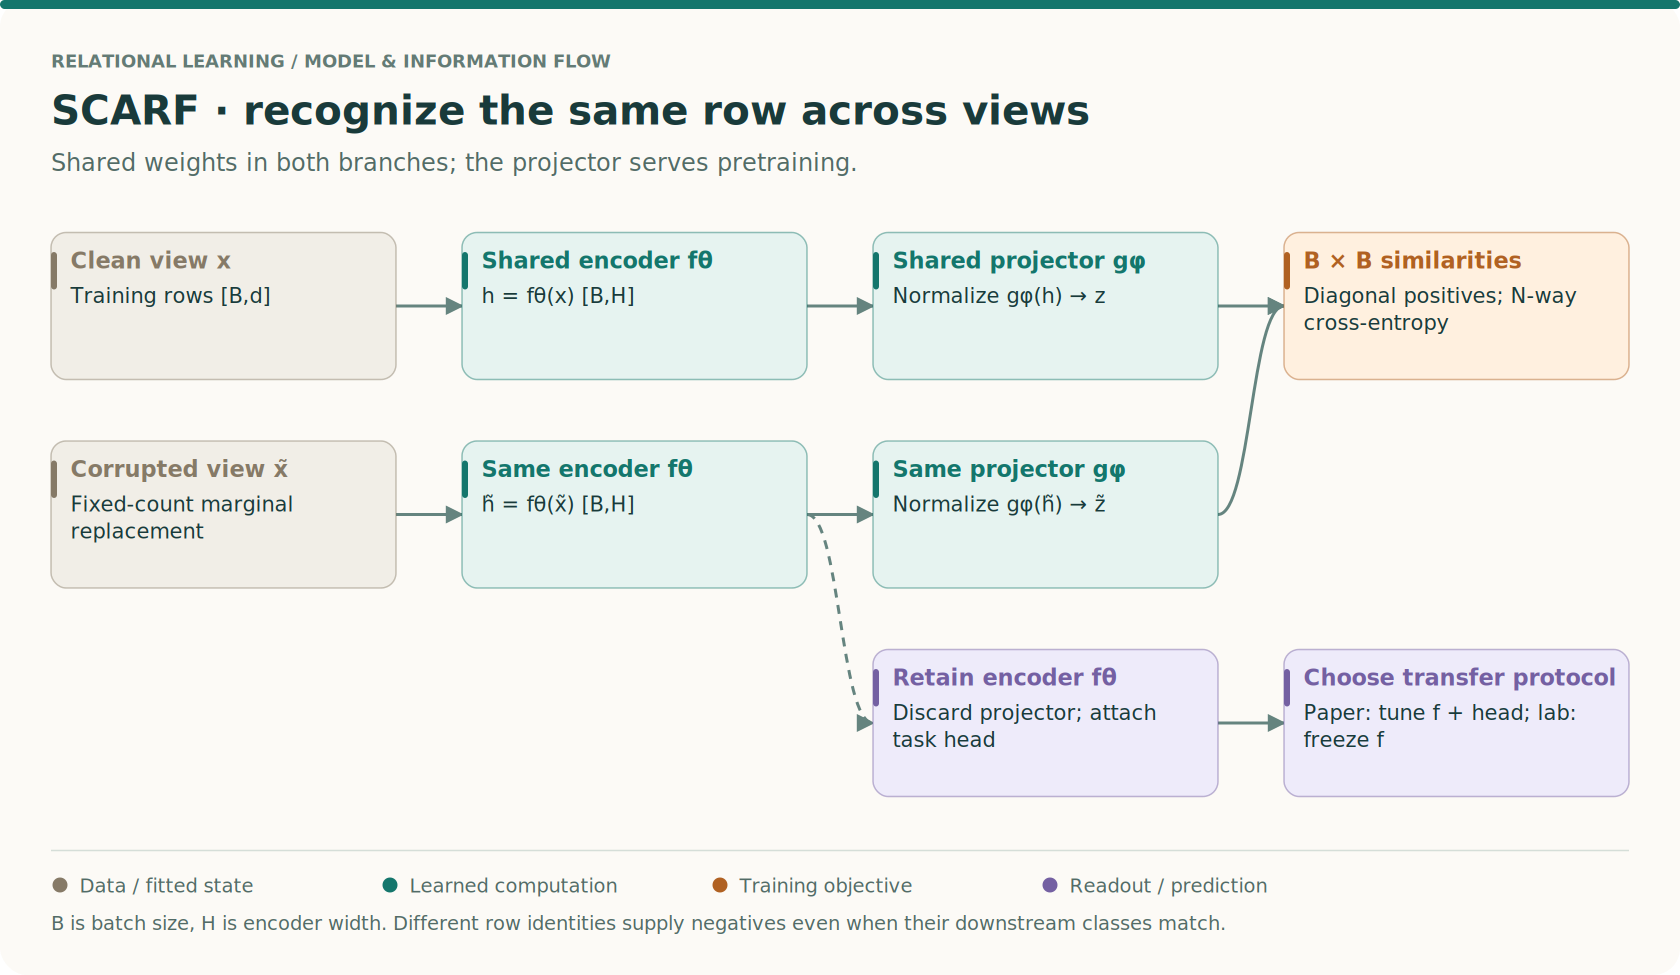</div><figcaption>Read the arrows as data dependencies. Teal: learned computation; amber: training objective; violet: readout or prediction. This is a computation overview; exact settings and paper/release differences are specified below.</figcaption></figure>

<figure class="model-map"><div class="model-map-scroll" tabindex="0" role="region" aria-label="Architecture diagram; scroll horizontally on narrow screens">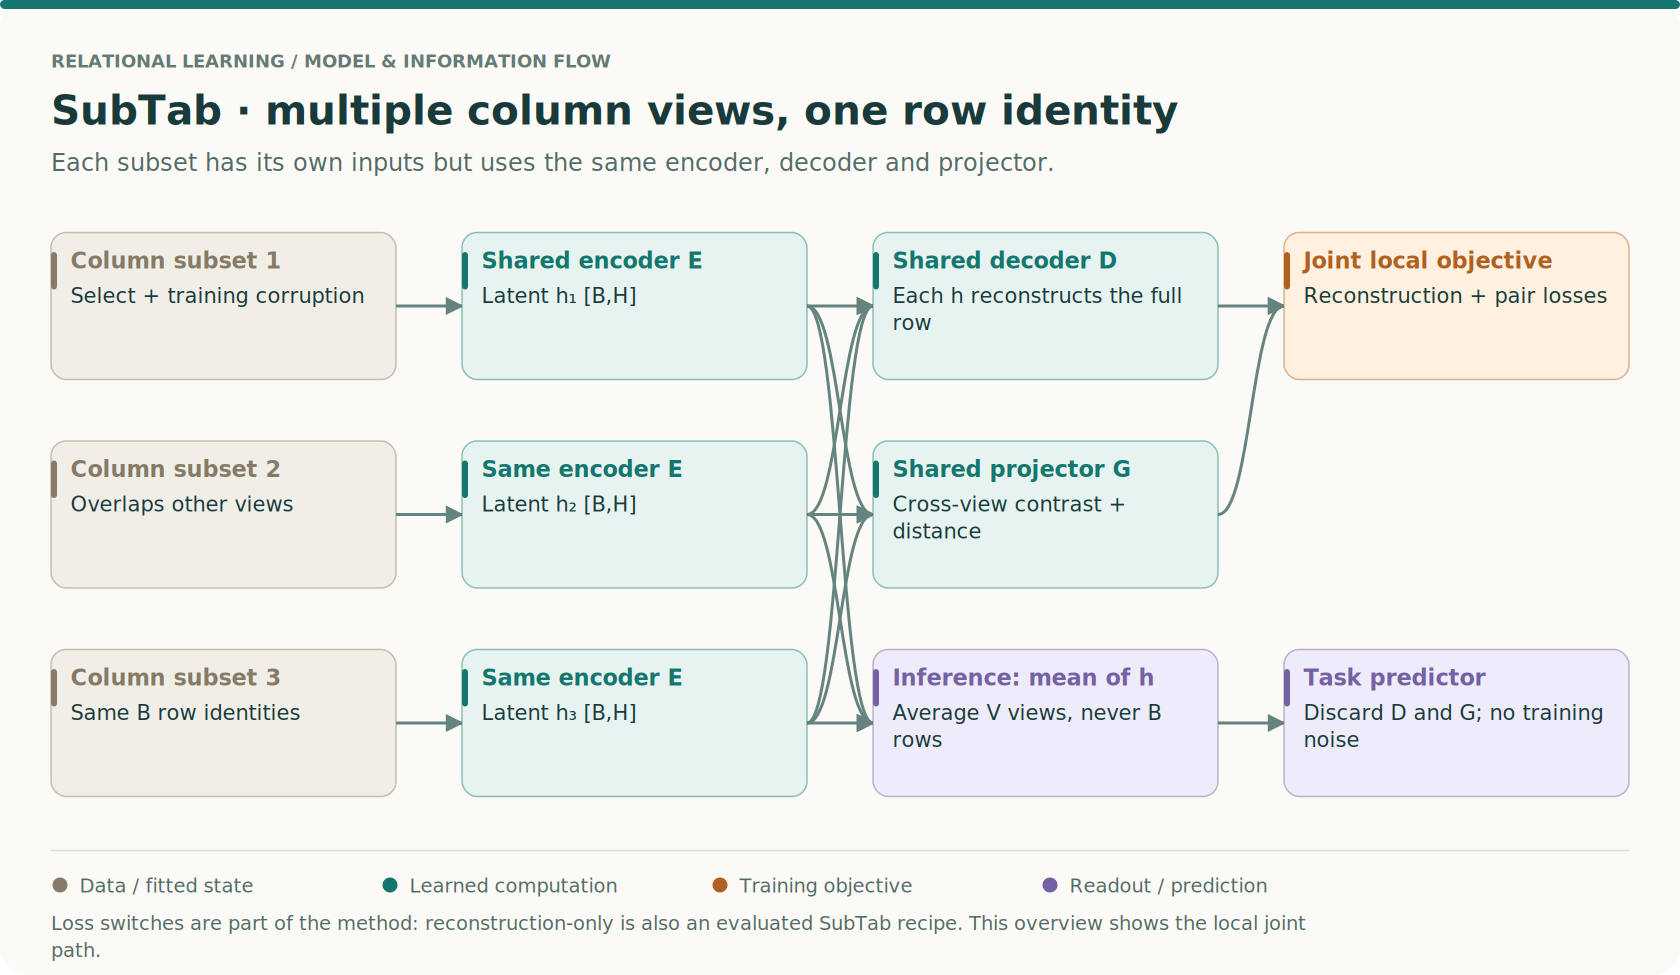</div><figcaption>Read the arrows as data dependencies. Teal: learned computation; amber: training objective; violet: readout or prediction. This is a computation overview; exact settings and paper/release differences are specified below.</figcaption></figure>

### Read two figures as competing design choices

Read [SCARF Figure 1 and Algorithm 1](https://arxiv.org/html/2106.15147v2#S3) beside [SubTab Figures 1–2 and §2](https://arxiv.org/html/2110.04361v1#S2). Annotate three differences: how views are constructed, what the loss compares, and which operation produces the representation used after pretraining. Our diagrams describe the shared computation; the body below distinguishes paper fine-tuning from the local frozen probes.

### Derive the axes before implementing the loss

1. **Keep identities attached.** Start with B rows. For SCARF, clean row i and corrupted row i remain a pair even if several values changed. Randomly shuffling only the corrupted rows while keeping diagonal targets silently makes the wrong pairs positive.
2. **Separate h from z.** h is the reusable encoder output. z is its projection for contrastive training. A good separation in z need not imply that every dimension of h has a direct semantic meaning. At transfer, follow the diagram to h rather than leaving the temporary projector attached by accident.
3. **Identify each softmax row.** In the SCARF layout a clean anchor compares with B corrupted candidates. With three identical candidates, the correct probability is 1/3 and cross-entropy is log(3), regardless of their absolute similarity. Thus “positive similarity is large” is not a sufficient training diagnostic.
4. **Change the view definition for SubTab.** Stack latent vectors as [V,B,H], where V counts feature subsets. Mean over axis 0 returns [B,H]. Mean over axis 1 returns [V,H] and mixes people or records together. Both calculations run successfully, but only the first preserves one representation per row.
5. **Name the pressure from each loss.** Reconstruction preserves information about the full row. Contrastive recognition separates row identities. Projection distance pulls same-row views together. They can disagree when an augmentation erases target-relevant information, and their numerical scales depend on how coordinates are reduced.

<details><summary>Predict the failure: two rows have the same class but are contrastive negatives</summary><p>The objective still pushes their projected representations apart because its target is row identity. Downstream supervision may later recover a shared class direction. This is why a contrastive objective and a classification objective should not be treated as interchangeable.</p></details>

**Your intermediate artifact:** produce a 3×3 candidate matrix with the positives marked, then a [3,2,2] SubTab tensor with the correct averaging axis marked. Explain why the two diagrams have different inference paths before running their probes.

<!-- depth-walkthrough:end -->



## 1 · From repairing values to identifying a companion

Imagine a customer row containing tenure, balance, visits, region and purchases. We create a second row by replacing three entries with values observed in the corresponding training columns. We still know which original produced it. That known relationship supplies a **positive pair** without a class label. Other rows’ corrupted companions become **negative candidates**. Here, “negative” means a different row identity; it does not mean a different class.

This distinction explains both the opportunity and the risk. Recognizing a companion encourages the model to retain clues that survive corruption. Yet two different customers who will both churn can be negatives. Conversely, replacing the sole feature that determines churn can destroy what makes the positive useful. The augmentation is therefore a hypothesis about which information should survive, not a proof of semantic equivalence.

SCARF applies this idea to marginal feature replacement and a contrastive objective, then transfers the learned encoder to supervised learning. Read [SCARF Algorithm 1 and Figure 1](https://arxiv.org/html/2106.15147v2#S3) alongside the next diagram. The paper’s experiments report improvements over its baselines across 69 classification datasets; our small frozen-probe experiment tests a narrower question.

### Model architecture · SCARF’s complete route

<figure><div class="figure-scroll" tabindex="0" role="region" aria-label="Scrollable scarf-architecture diagram">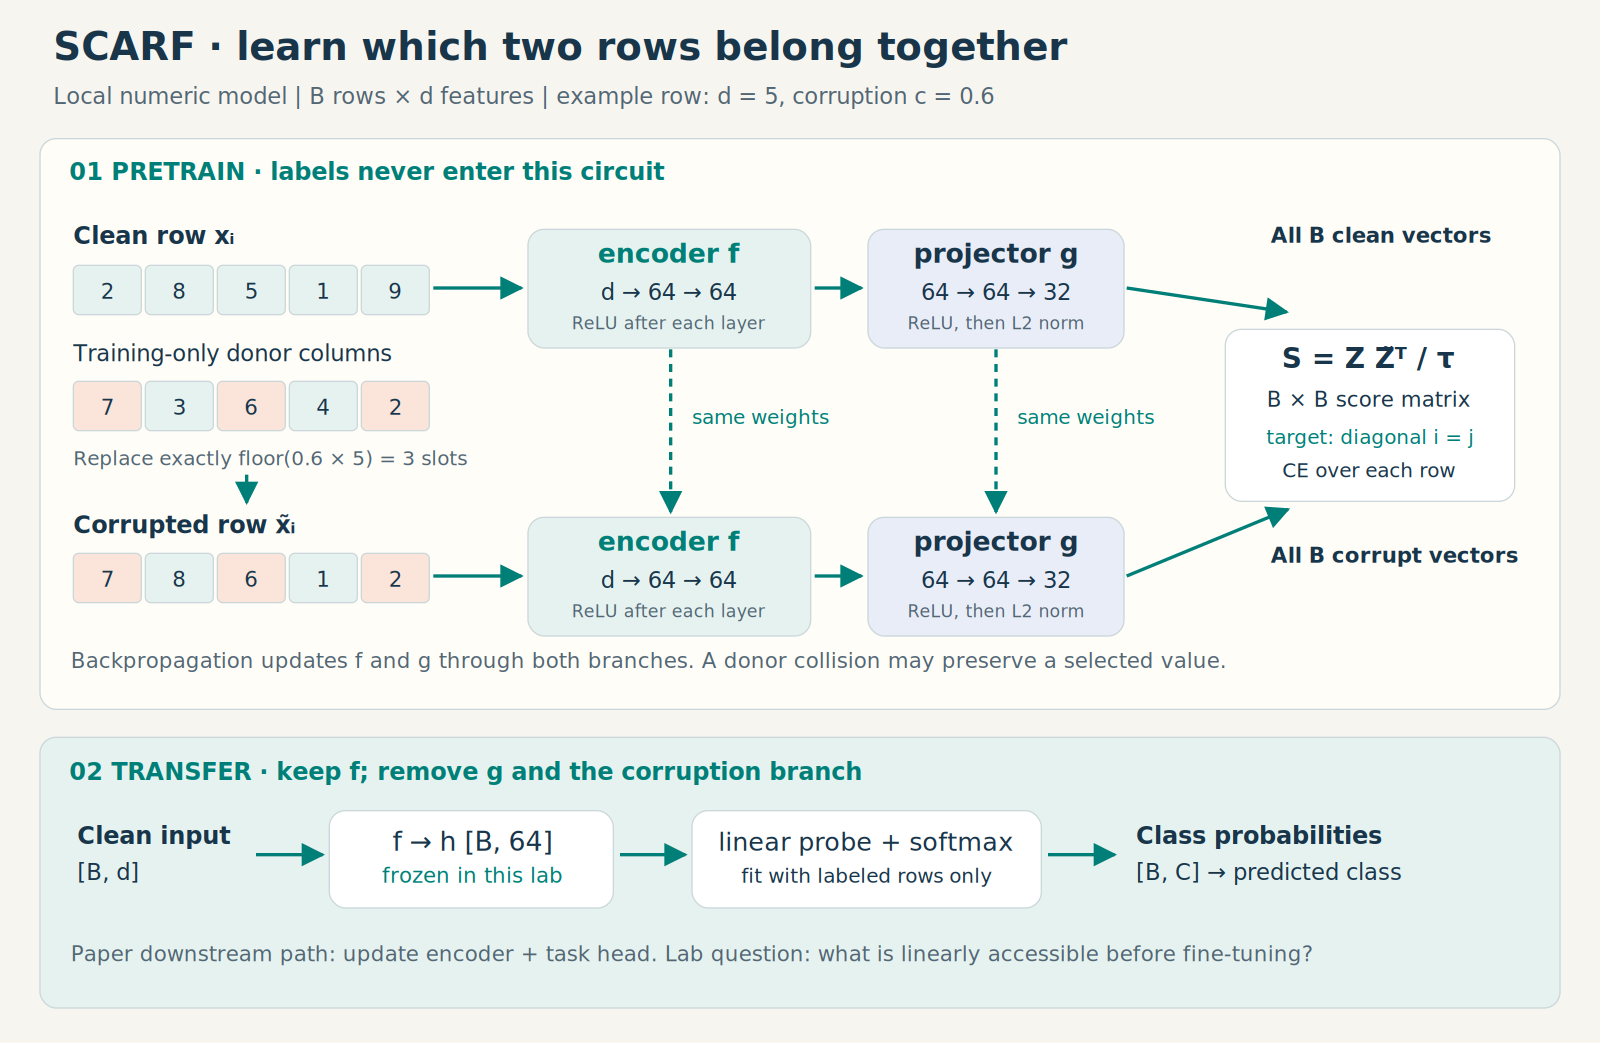</div><figcaption>Complete local SCARF path. The two branches share weights; row identity supplies the diagonal targets. At transfer, keep the encoder and discard the projector. The diagram distinguishes the frozen lab probe from paper fine-tuning. Values in the five-column row are an illustrative corruption trace. On small screens, scroll the diagram horizontally.</figcaption></figure>

Follow the orange cells first. They change the second input but leave its identity paired with the first input. Then follow both teal branches: the encoder weights are shared, so this is one function evaluated twice. Its output **h** is the representation we intend to reuse. A separate **projection head**, g, transforms h into z for the pretraining comparison. The final normalization makes the comparison depend on direction rather than vector length.

The loss sends gradients through both branches, updating f and g. At transfer, the corruption machinery and g disappear. The paper fine-tunes an encoder and a task head. Our **linear probe** instead freezes f and learns only a linear classifier on h. That deliberate change asks whether useful class information is already accessible through a linear boundary. It does not measure the full benefit of supervised fine-tuning.

**Local architecture details:** numeric inputs have shape [B,d], where B is batch size and d is feature count. Two linear layers with ReLU produce h of shape [B,64]. ReLU maps negative activations to zero. The projector maps 64→64→32, with ReLU between layers; its vectors are normalized inside the loss. A C-class probe maps h to C scores, then softmax turns those scores into probabilities. These compact widths are our teaching configuration, not a claim of paper-model parity.

The paper’s experimental network is larger: a four-layer encoder and two-layer pretraining/classification heads, with hidden width 256. It uses validation-based stopping and supervised fine-tuning. The diagram deliberately pictures our runnable compact variant; the shared-branch logic and transfer boundary carry over, while parameter counts and evaluation claims do not.

### A corruption trace you can audit

For x = [2,8,5,1,9], rate c = 0.6 selects exactly floor(5×0.6) = 3 positions. Suppose they are columns 0, 2 and 4, and independent donor draws return 7, 6 and 2. The companion becomes [7,8,6,1,2]. Each donor value comes from its own column’s training distribution; selecting one whole donor row would preserve extra cross-column dependence and define another augmentation.

The selected-count rule also differs from independently flipping a coin for every feature: a coin rule has a random count. Neither rule guarantees that selected values actually change. If a donor returns 5 for column 2, that selected cell remains 5. These distinctions are exactly what the first lab CHECK tests.



## 2 · Turn companion recognition into a differentiable loss

Now the architecture needs a precise training instruction. For each clean vector zᵢ, compare it with every corrupted vector z̃ⱼ in the batch. Define cosine similarity sᵢⱼ = (zᵢ·z̃ⱼ)/(‖zᵢ‖‖z̃ⱼ‖). A value near 1 means their directions align. Divide by a positive **temperature** τ before softmax; smaller τ makes score differences more decisive.

The N×N score matrix is a classification problem with N choices per row. For clean anchor i, its correct choice is corrupted candidate i. Thus the diagonal contains positives. The denominator **includes the positive**:

<p class="formula">pᵢ = exp(sᵢᵢ/τ) / Σⱼ exp(sᵢⱼ/τ)<br>ℓᵢ = −log pᵢ; L = meanᵢ ℓᵢ</p>

Cross-entropy with targets [0,1,…,N−1] implements that instruction stably, without explicitly exponentiating large scores. The paper writes the denominator as a mean, so its displayed objective equals this cross-entropy minus log N. That additive constant leaves the gradients unchanged for fixed N. It does mean that raw loss numbers require a stated convention.

**Work it out.** Take two unit vectors [1,0] and [0,1] in each branch, with τ=1. The score matrix is [[1,0],[0,1]]. Each correct probability is e/(e+1)=0.7311, and the cross-entropy is 0.3133. Removing the diagonal would remove the correct answer. Adding clean-to-clean candidates would change the learning problem.



Notebook prediction: recompute the example at τ=0.5 before reading further. Then change the candidate layout. With both views as anchors, each anchor has one matching companion and **two** orthogonal negatives in this example, producing log(1+2/e)=0.5514. That is the layout used by the SubTab contrastive operator we audit, not SCARF’s N-way layout.

<details><summary>Reasoning check: can collapse look aligned?</summary><p>Yes. If all N vectors are identical, every positive has cosine similarity 1, but so does every negative. The correct probability is 1/N and the cross-entropy is log N. Alignment alone is insufficient. For N=1, there is no negative competition and this recognition objective carries no useful signal.</p></details>

The derivative with respect to a row’s unscaled similarity is (pᵢⱼ − 1[j=i])/τ, before the batch mean. A wrong candidate with high probability gets a stronger downward signal. This explains why temperature changes optimization, and why same-class false negatives can matter: their similarity is discouraged despite their shared downstream label.



## 3 · What if the view is a different set of columns?

SCARF retains the full input width and replaces values. Suppose instead that measurements arrive in groups: one system knows transactions, another knows visits. A representation should combine what each partial observation can tell us. This motivates SubTab’s feature subsets.

SubTab shares an encoder across overlapping column windows, reconstructs the full row, and can add contrastive and projection-distance losses. At prediction, it aggregates the subset representations. Read [SubTab §2 and Figures 1–2](https://arxiv.org/html/2110.04361v1#S2). The important shift is that reconstruction and agreement now work together: each subset must support a useful account of the whole.

### Model architecture · SubTab’s complete route

<figure><div class="figure-scroll" tabindex="0" role="region" aria-label="Scrollable subtab-architecture diagram">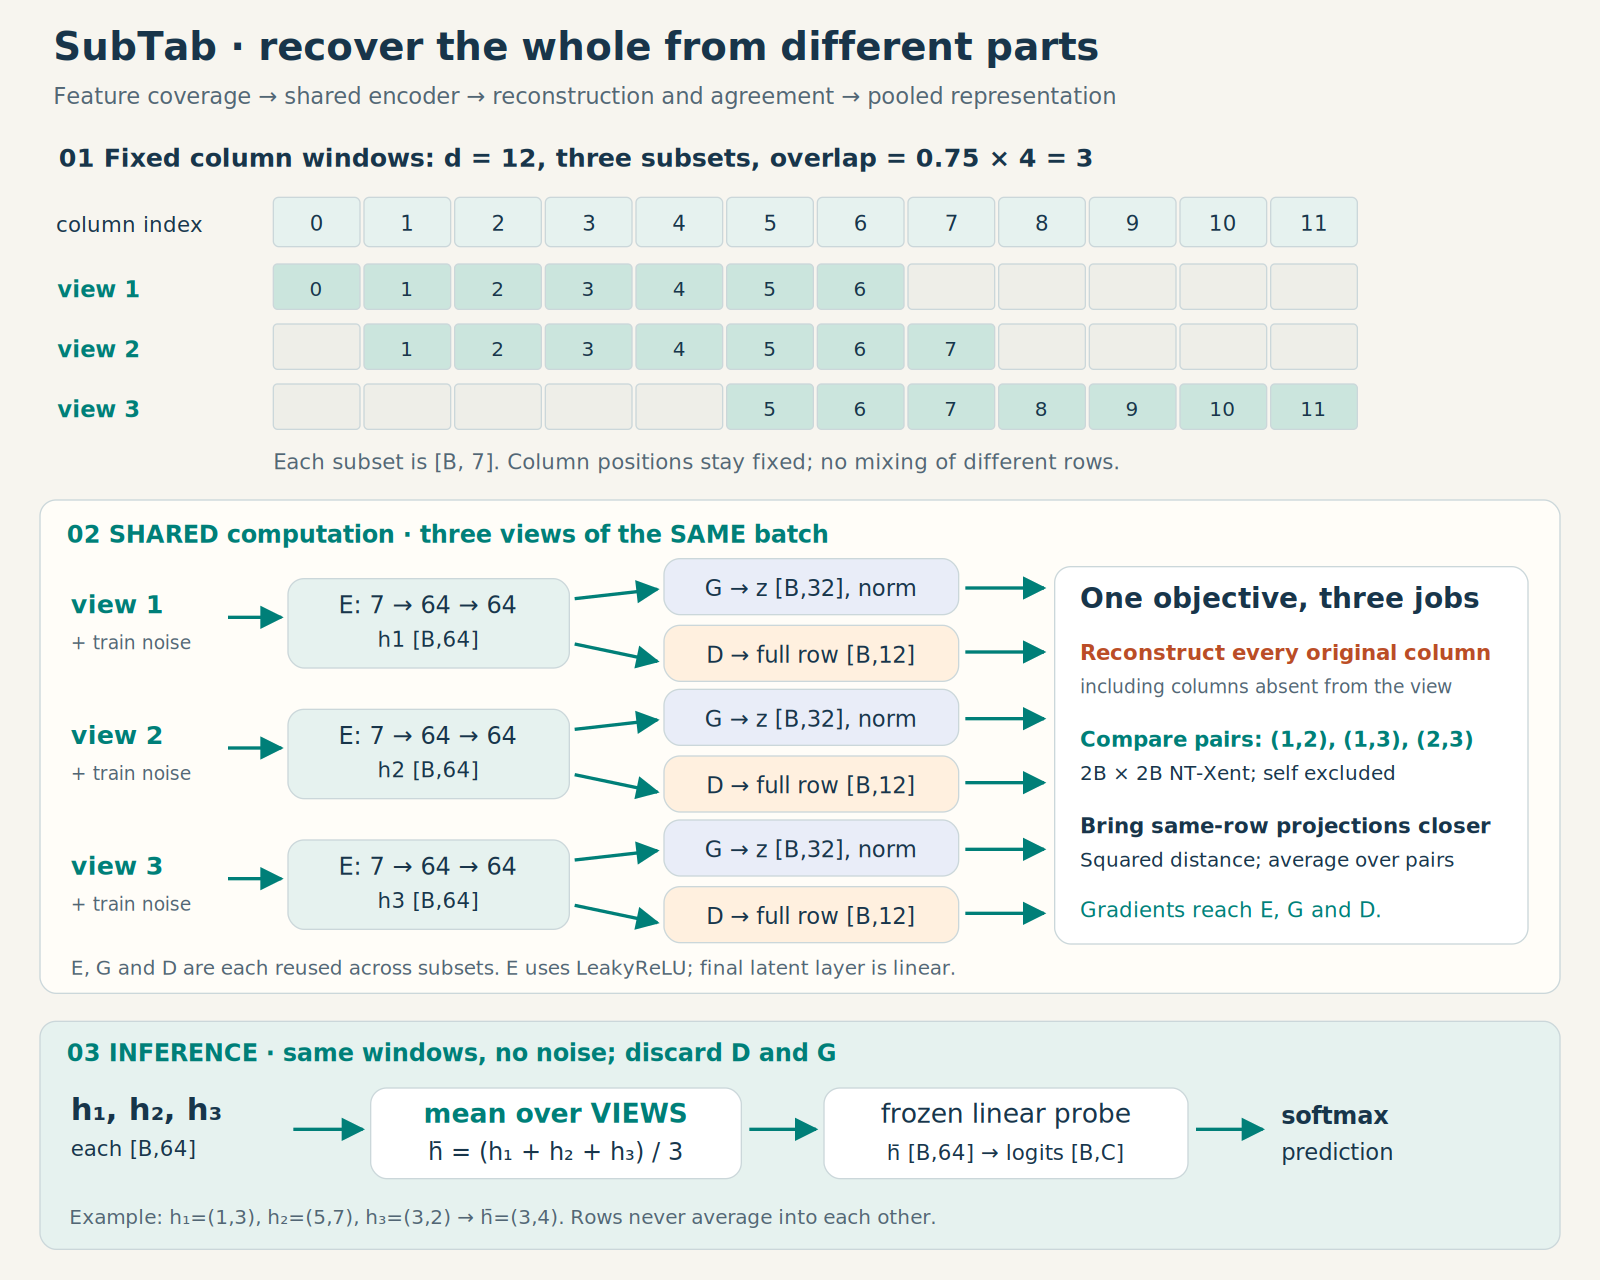</div><figcaption>Complete local SubTab path. The coverage map shows which measurements each view can use. All views share E, G and D; reconstruction and pair losses train them together. Inference averages latent vectors for the same row before the frozen probe. The twelve-column layout and latent mean are illustrative, not measured model outputs. On small screens, scroll the diagram horizontally.</figcaption></figure>

Start at the coverage map rather than the neural layers. Row identity is preserved horizontally across all three views; the available columns change. The three paths use the same encoder E. Each latent vector h feeds two destinations: decoder D predicts the full original row, while projector G supplies a space for agreement losses. Reconstructing unseen columns forces the decoder to use statistical relationships, though those relationships need not be useful for the class label.

The bottom path answers the deployment question. We retain the same subset layout, remove training noise, evaluate E for each subset, and average the latent vectors for each row. We discard D and G. Averaging over the **row** axis would mix different examples and destroy their identities; the third lab task makes that mistake observable.

The pictured d=12 layout follows the released indexing with three subsets and overlap 0.75: [0…6], [1…7], [5…11]. “75% overlap” here is relative to the base width floor(d/3)=4, not the resulting seven-column view. If d is not divisible by three, this released formula can omit trailing columns from every encoder input. Our implementation exposes that behavior; the decoder still predicts all d columns. Inspect `subsets(13)` before interpreting the wine result.

The losses are configurable, rather than mandatory ingredients of every reported result. In particular, the paper’s additional OpenML experiments use reconstruction-only SubTab. Our joint-versus-reconstruction comparison asks whether adding agreement helps this local recipe; it does not assume the most elaborate loss must win.

### Why three loss terms?

Reconstruction asks, “can this part predict the whole?” Contrastive recognition asks, “which other-view vector belongs to this row?” Squared projection distance asks, “how close are the same row’s two projections?” They impose different constraints. A constant representation minimizes agreement distance but cannot generally reconstruct varying rows or identify companions.

For the local joint model, average reconstruction over the three views. For each of the three view pairs, add symmetric NT-Xent and squared projection distance, then average these pair losses. NT-Xent concatenates two B-row views, masks self-similarity, and keeps the paired companion among 2B−1 candidates. This is the second candidate layout in the worked example above.

The [released loss code](https://github.com/AstraZeneca/SubTab/blob/aa3ab1b97231fc37229ef3e55d98ae13bdbfb4fc/utils/loss_functions.py) sums squared errors over coordinates and averages over rows. We preserve that reduction. For reconstruction residual [1,2,0], its row contribution is 5, not 5/3. Consequently, dimensionality affects the balance with the contrastive term. Quietly replacing this with an all-cell mean changes the method.



The aggregation trace uses h₁=(1,3), h₂=(5,7), h₃=(3,2). Their mean is (3,4). Omit the third view and predict the new mean: check against (3,5). This is a computation exercise, not a claim that losing a view improves or harms classification; that requires a measured downstream task.



## 4 · From an appealing objective to an honest test

We now have two plausible solutions. Plausibility is not evidence of useful representations. This connects back to [Lesson 59’s selection boundaries](../lessons/0059-validation-set-overfitting.html): representation training, probe fitting, regularization selection, and final scoring each need an information boundary. It also connects to Lesson 71’s label accounting: validation labels are part of the annotation cost.

**Local protocol, fixed before scoring:** three real datasets bundled with scikit-learn—wine, breast cancer and digits—each with three paired split/model seeds (0,1,2). Stratified splits allocate approximately 70%/10%/20% to train/validation/test. Pretraining and input standardization use only the training rows; labels are hidden during pretraining. The benchmark split designer uses labels for stratification; the pretrainer receives no labels. The probe sees labels from 25% of training rows, and selects C from {0.1,1,10} using validation accuracy. Its feature standardizer is fitted on those labeled training rows. Validation labels therefore add roughly 10% of the full dataset to the labeled budget. The split record gives exact counts.

We pretrain for 40 fixed epochs with Adam at 0.001, batches of at most 64, no early stopping. SCARF uses c=0.6 and τ=1. SubTab uses three windows, overlap 0.75, and independent Gaussian noise with standard deviation 0.1 on entries selected with probability 0.3 during training only. All probe encoders remain frozen. Test rows are transformed and scored only after the training choices are fixed; no statistic is fitted to them.

| Arm | What it asks | What the comparison cannot isolate |
|---|---|---|
| Raw standardized features | Can a linear classifier already solve the task? | The value of a nonlinear supervised network |
| Random frozen encoder | Does architecture alone supply useful features? | Optimization without the SSL objective |
| SCARF | Does corrupted-companion training help over the identical random encoder? | Which individual pretraining choice caused a gain |
| SCARF c=0 | What changes when replacement is removed but instance recognition remains? | A no-training baseline; this arm still learns |
| SubTab reconstruction | What can subset reconstruction learn? | The effect of subsetting versus a full-row autoencoder |
| SubTab joint | What do contrastive and distance terms add together? | Their separate effects, or a perfectly matched SCARF architecture |



Predict which dataset will show the largest SCARF gain over its random encoder, and whether raw features might still win. Then reveal the evidence. These arms compare **recipes**, not a fair contest that isolates every architecture decision.

**Author-reference accuracy (%), mean ± sample SD. These are saved author results, not your current kernel output.**

| Dataset | Raw | Random | SCARF | SCARF c=0 | SubTab R | SubTab R+C+D |
|---|---|---|---|---|---|---|
| wine | 99.07 ± 1.60 | 88.89 ± 14.43 | 96.30 ± 4.24 | 93.52 ± 11.23 | 93.52 ± 4.24 | 92.59 ± 5.78 |
| breast_cancer | 95.91 ± 2.53 | 94.74 ± 1.75 | 95.61 ± 1.52 | 95.91 ± 1.83 | 91.52 ± 2.21 | 92.11 ± 1.75 |
| digits | 94.07 ± 0.85 | 83.33 ± 1.73 | 90.28 ± 3.47 | 88.52 ± 0.58 | 90.65 ± 0.16 | 90.46 ± 1.70 |

**Paired SCARF minus random-encoder gains (percentage points):**

- breast_cancer: +0.88, +0.00, +1.75.
- digits: +8.61, +7.78, +4.44.
- wine: +0.00, +19.44, +2.78.

**Observed in this run:** SCARF improves the random encoder at the mean on all three datasets, but the raw-feature probe has higher mean accuracy on all three. Joint SubTab does not consistently beat reconstruction-only SubTab. These outcomes separate learning a representation from choosing the best prediction recipe.

Read these gains alongside the raw-feature arm. A positive gain over random features need not beat the original inputs. Differences between SubTab and SCARF also include different architectures and objectives. This experiment cannot attribute them solely to the choice of views.


<figure><div class="figure-scroll" tabindex="0" role="region" aria-label="Scrollable results diagram">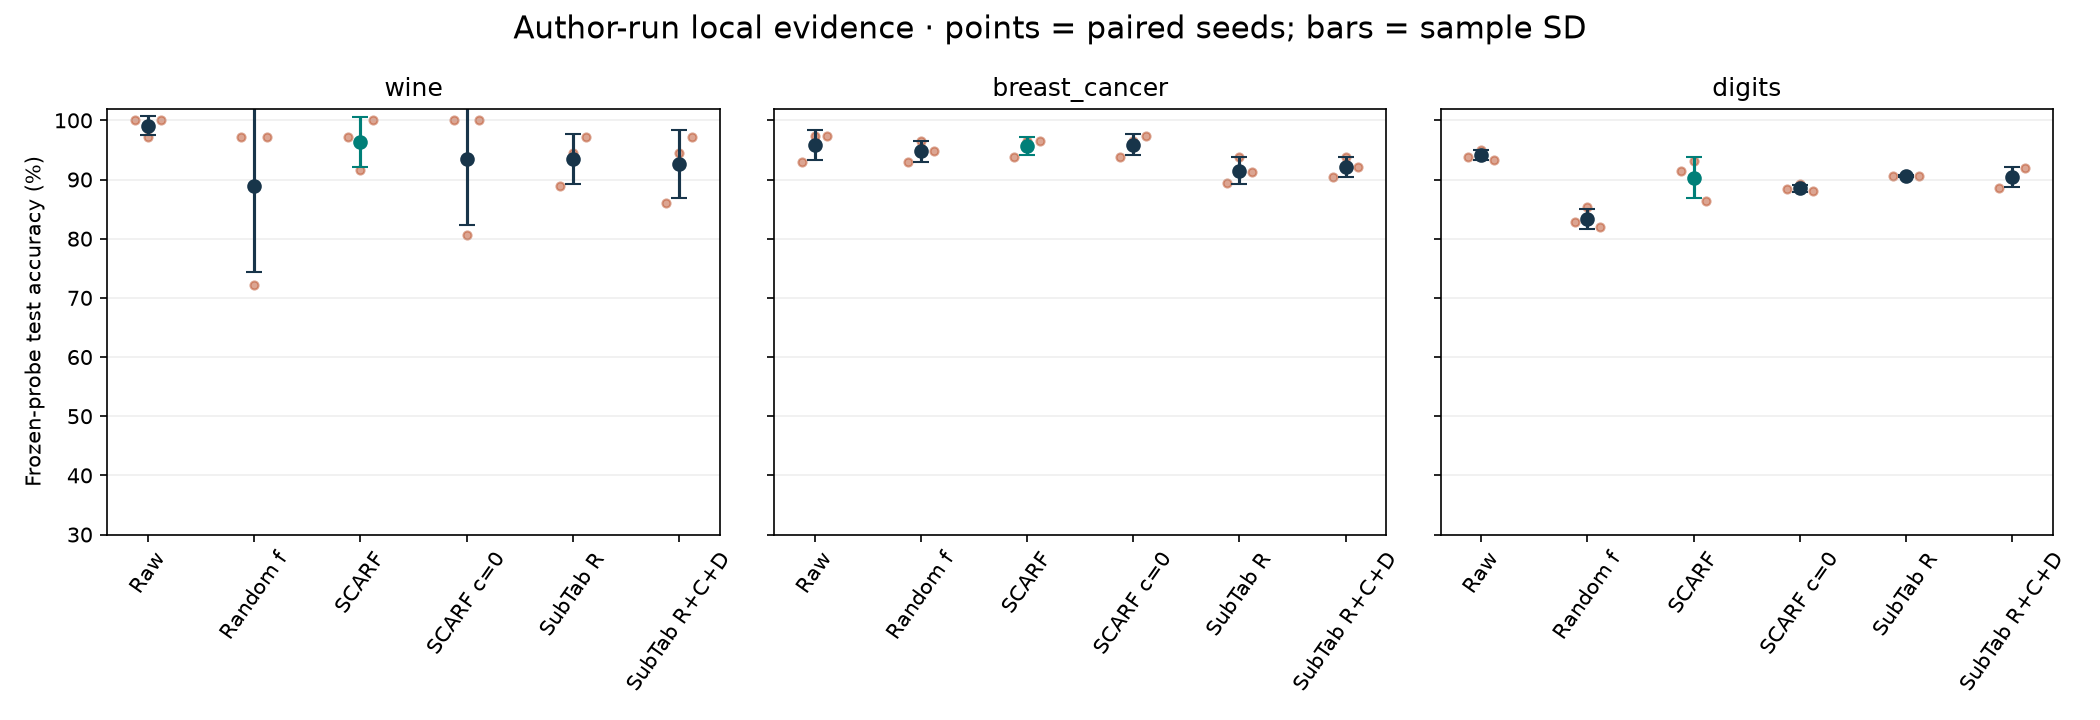</div><figcaption>Author-run measurements: three real datasets, three paired split/initialization seeds, fixed frozen-probe protocol. Orange points are individual seeds; bars are sample SD, not confidence intervals over datasets. R = reconstruction, C = contrastive recognition, D = projection distance. On small screens, scroll the diagram horizontally.</figcaption></figure>

<figure><div class="figure-scroll" tabindex="0" role="region" aria-label="Scrollable ranks diagram">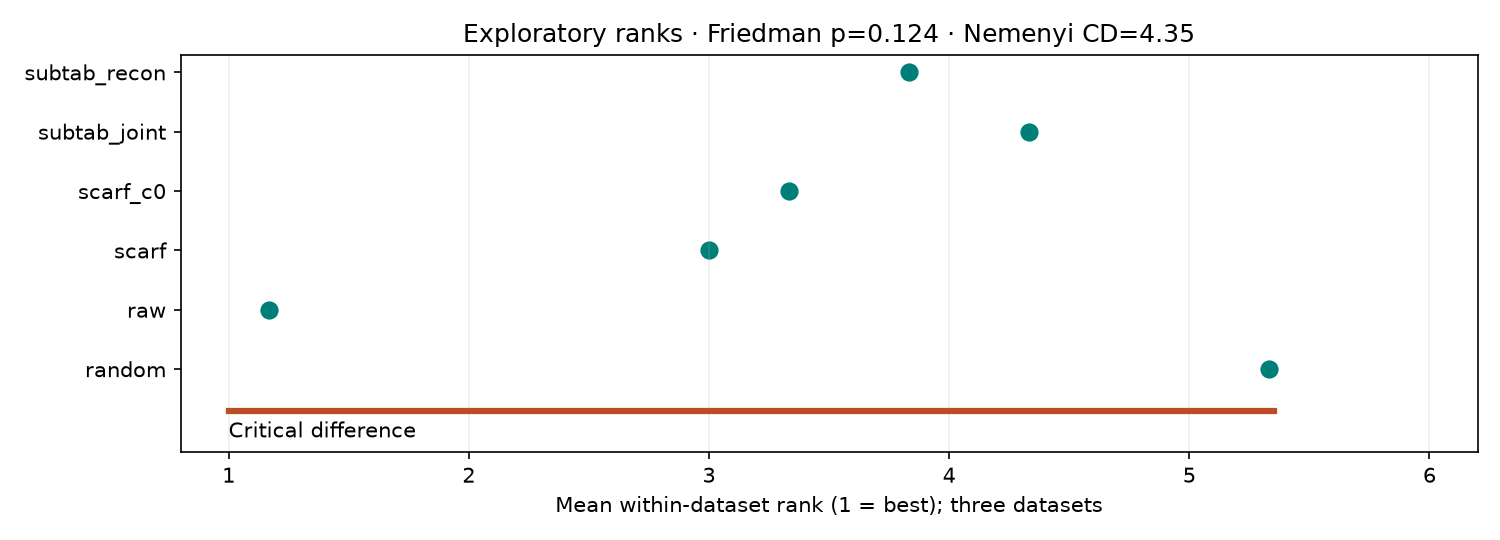</div><figcaption>Dataset-balanced rank audit of these six local recipes. Seeds are averaged before ranking. The orange segment is the Nemenyi critical difference; comparisons exceeding it would pass that exploratory threshold. Three selected datasets provide weak evidence for general rankings. On small screens, scroll the diagram horizontally.</figcaption></figure>

Sample standard deviation describes variation across these paired seeds. The seeds change splits and initialization together, so this is neither a confidence interval over new datasets nor separate estimates of those two variance sources. Ranks first average seeds within each dataset, then weight the three datasets equally. The rank diagram and Friedman/Nemenyi audit are exploratory; three chosen datasets cannot establish broad superiority or equivalence.

### What was actually reproduced?

| Evidence bucket | Status and boundary |
|---|---|
| SCARF equation | Independent numeric checks; paper’s N-way layout, exact selected count, and marginal donors; CE offset disclosed |
| SubTab released operator | Pinned NT-Xent outputs and input gradients checked against the author release on two batch sizes |
| Local training | Fresh fits and frozen probes on three datasets; table and seed-level predictions archived |
| Original benchmark tables | **INCOMPARABLE**: datasets, architectures, schedules, downstream protocol and repetitions differ |
| Larger run | **NOT_RUN** until the explicit operator is executed; increasing epochs alone does not establish fidelity |
| Live Colab and deployment | **NOT_CHECKED** in this delivery; local notebook and browser checks are recorded separately |

The paper-code comparison checks an operator, not the full released model or training procedure. Read the [reproduction contract](../labs/l072-reproduction.md) and [source audit](../labs/_sources_l072.json) before making a stronger claim.



## 5 · Implement, interpret, and carry the question forward

Open the [lab preview](../labs/html/0072-scarf-subtab-contrastive-views.html#lab-exercises) or [student notebook](../labs/0072-scarf-subtab-contrastive-views.ipynb). The model and training loop are visible. Your three TODOs implement column-respecting corruption, SCARF’s N-way loss, and SubTab’s view aggregation. Every TODO has an immediate independent CHECK and is called by the actual experiment. Passing these fixtures is necessary; the written interpretation remains part of the exit.

**EXIT:** produce all 54 evaluation records, report each paired SCARF-minus-random gain, account for validation labels, and explain one case where the result limits your initial prediction. Diagnose how replacing exact-count corruption with independent masks, confusing N-way with 2N-way loss, or averaging different rows changes the experiment. Explain why a better frozen probe is not automatically evidence of better fine-tuning.



Tomorrow, explain both diagrams from a blank page before reopening them. In one week, recreate the two-candidate loss calculation and the subset mean from memory. Ask the tutor about any unclear step, and paste your EXIT interpretation for feedback; creating this lesson does not mark it mastered.

**The next question:** once we can build these representations, when is their extra training worthwhile? Planned Lesson 73 varies label availability and the match between unlabeled and downstream data. The connection is causal: today fixes the machinery; next we vary the conditions under which that machinery should help. Later, relational pretraining will inherit the same question about which entity views preserve task information.

**Primary reading:** [Bahri et al., SCARF, Algorithm 1 and Figure 1](https://arxiv.org/html/2106.15147v2), then [Ucar et al., SubTab, §2 and Figures 1–2](https://arxiv.org/html/2110.04361v1). Use the [printable reference](../reference/0072-scarf-subtab-contrastive-views.html) after attempting retrieval.



## Paper reproduction track

The [paper reproduction section](../labs/html/0072-scarf-subtab-contrastive-views.html#paper-reproduction) in the companion notebook includes the full runnable paper/release implementation after EXIT, separately from its compact teaching experiment. Read the [reproduction guide](../labs/reproductions/README.md) for the named target, full-data commands, source pins and remaining gaps. The full model and training code are visible in the notebook. Smoke execution and source equivalence are checks; published-result reproduction requires the aligned experiment and its measured comparison.


<a id="lab-exercises"></a>
## Lab exercises · make the computation yours

The figures and table above are author reference material. The following experiment will call your definitions in this kernel. Do not replace TODOs with imports from the solution module.

In [ ]:
# PROVIDED: dependencies
import copy
import hashlib
import itertools
import platform
import time
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
from sklearn import __version__ as sklearn_version
from sklearn.datasets import load_breast_cancer, load_wine, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from scipy.stats import rankdata, friedmanchisquare, studentized_range
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
torch.set_num_threads(1)

### TODO · corrupt

**Goal:** Produce a new [B,d] tensor. For selected cells use bank[donor row, original column]; preserve other cells and do not mutate x.

**Predict first:** Draw a two-row, three-column example first. A donor row index applies to one cell, not its whole row.

**Connection:** This creates SCARF’s positive companion without exposing labels.

In [ ]:
def corrupt(x, bank, mask, donors):
    """Produce a new [B,d] tensor. For selected cells use bank[donor row, original column]; preserve other cells and do not mutate x."""
    raise NotImplementedError("corrupt")

In [ ]:
# CHECK: independent arithmetic
x0=torch.tensor([[1.,10.,100.],[2.,20.,200.]])
b0=torch.tensor([[3.,30.,300.],[4.,40.,400.]])
m0=torch.tensor([[True,False,True],[False,True,False]])
i0=torch.tensor([[1,0,0],[0,1,1]])
assert torch.equal(corrupt(x0,b0,m0,i0),torch.tensor([[4.,10.,300.],[2.,40.,200.]]))
assert x0[0,0]==1, 'Clean input was mutated'
assert torch.equal(corrupt(x0,x0,torch.zeros_like(m0),i0),x0)
print("corrupt: passed")

### TODO · scarf_loss

**Goal:** Return the mean N-way cross-entropy for cosine scores / tau. Target i is changed row i. Preserve autograd and include the positive in the denominator.

**Predict first:** Distinguish the candidate axis from the embedding axis. Work out the two orthogonal vectors before coding.

**Connection:** This converts companion identity into the training signal drawn in the SCARF diagram.

In [ ]:
def scarf_loss(clean, changed, tau=1.):
    """Return the mean N-way cross-entropy for cosine scores / tau. Target i is changed row i. Preserve autograd and include the positive in the denominator."""
    raise NotImplementedError("scarf_loss")

In [ ]:
# CHECK: independent arithmetic
z0=torch.eye(2,requires_grad=True)
l0=scarf_loss(z0,z0,1.)
assert abs(l0.item()-np.log1p(np.exp(-1)))<1e-6, 'Expected N-way loss 0.3133, not 2N-way loss'
l0.backward();assert z0.grad.abs().sum()>0
assert abs(scarf_loss(torch.ones(3,2),torch.ones(3,2)).item()-np.log(3))<1e-6
assert torch.allclose(scarf_loss(3*z0,z0),scarf_loss(z0,z0)), 'Cosine removes positive rescaling'
print("scarf_loss: passed")

### TODO · aggregate_views

**Goal:** Input [views, rows, hidden]; average representations across views while preserving each row. Return [rows, hidden].

**Predict first:** Label all three axes on paper. Use different values for the two rows so the wrong axis cannot silently pass.

**Connection:** This is the handoff from SubTab pretraining to one representation per prediction row.

In [ ]:
def aggregate_views(h):
    """Input [views, rows, hidden]; average representations across views while preserving each row. Return [rows, hidden]."""
    raise NotImplementedError("aggregate_views")

In [ ]:
# CHECK: independent arithmetic
h0=torch.tensor([[[1.,3.],[2.,4.]],[[5.,7.],[6.,8.]]])
assert torch.equal(aggregate_views(h0),torch.tensor([[3.,5.],[4.,6.]])), 'Average views, never rows'
assert torch.equal(aggregate_views(h0[:1]),h0[0])
print("aggregate_views: passed")

### PROVIDED · Two view rules and two candidate matrices

SCARF counts selected positions exactly. SubTab keeps fixed windows; its symmetric contrastive loss masks only self. Compare these definitions to the two architecture diagrams.

In [ ]:
# PROVIDED: subtab_loss
def subtab_loss(a, b, tau=1.):
    """Symmetric 2N NT-Xent: exclude self, retain cross-view positive."""
    n = len(a)
    z = F.normalize(torch.cat([a, b]), dim=1)
    scores = z @ z.T / tau
    scores = scores.masked_fill(torch.eye(2*n, dtype=torch.bool, device=z.device), -torch.inf)
    targets = (torch.arange(2*n, device=z.device) + n) % (2*n)
    return F.cross_entropy(scores, targets)

In [ ]:
# PROVIDED: subsets
def subsets(d, count=3, overlap=.75):
    """Released SubTab contiguous layout, including its floor-division tail behavior."""
    width = d // count
    extra = int(overlap * width)
    return [list(range(0 if i == 0 else i*width-extra,
                       width+extra if i == 0 else (i+1)*width)) for i in range(count)]

In [ ]:
# PROVIDED: draw_view
def draw_view(x, bank, rate=.6):
    q = int(rate * x.shape[1])
    mask = torch.zeros_like(x, dtype=torch.bool)
    chosen = torch.rand_like(x).argsort(dim=1)[:, :q]
    mask.scatter_(1, chosen, True)
    donors = torch.randint(len(bank), x.shape, device=x.device)
    return corrupt(x, bank, mask, donors)

### PROVIDED · Visible model architecture

Trace h, z and reconstruction. Find shared weights, discarded heads, training noise and the call to your aggregation function.

In [ ]:
# PROVIDED: SCARF
class SCARF(nn.Module):
    """Local compact f: d->64->64; g: 64->64->32; ReLU after hidden layers."""
    def __init__(self, d, width=64):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(d,width),nn.ReLU(),nn.Linear(width,width),nn.ReLU())
        self.projector = nn.Sequential(nn.Linear(width,width),nn.ReLU(),nn.Linear(width,32))
    def forward(self, x):
        return self.projector(self.encoder(x))
    def represent(self, x):
        return self.encoder(x)

In [ ]:
# PROVIDED: SubTab
class SubTab(nn.Module):
    """Shared subset encoder, full-row decoder and projector; local compact widths."""
    def __init__(self, d, width=64):
        super().__init__()
        self.columns = subsets(d)
        self.encoder = nn.Sequential(nn.Linear(len(self.columns[0]),width),nn.LeakyReLU(),nn.Linear(width,width))
        self.projector = nn.Sequential(nn.Linear(width,width),nn.LeakyReLU(),nn.Linear(width,32))
        self.decoder = nn.Sequential(nn.Linear(width,width),nn.LeakyReLU(),nn.Linear(width,d))
    def forward(self, x, noise=False):
        hs=[]
        for cols in self.columns:
            view=x[:,cols]
            if noise:
                view=view + .1*torch.randn_like(view)*(torch.rand_like(view)<.3)
            hs.append(self.encoder(view))
        h=torch.stack(hs)
        z=F.normalize(self.projector(h),dim=-1)
        return h,z,self.decoder(h)
    def represent(self, x):
        return aggregate_views(self(x,noise=False)[0])

### PROVIDED · The unlabeled training loop

No y argument exists. Locate the calls to your loss and corruption. Reconstruction sums feature errors before averaging rows, preserving the audited reduction.

In [ ]:
# PROVIDED: pretrain
def pretrain(x, kind, seed, epochs=40, device='cpu'):
    """No labels or held-out rows enter this function. Fixed epochs; no selection."""
    torch.manual_seed(seed)
    net=(SubTab(x.shape[1]) if kind.startswith('subtab') else SCARF(x.shape[1])).to(device)
    x=torch.as_tensor(x,dtype=torch.float32,device=device)
    initial=copy.deepcopy(net.state_dict())
    opt=torch.optim.Adam(net.parameters(),lr=.001)
    history=[]
    if kind=='random':
        return net, {'loss': [], 'parameter_delta': 0.}
    for epoch in range(epochs):
        values=[]
        for ix in torch.randperm(len(x),device=device).split(64):
            if len(ix)<2: continue
            batch=x[ix]
            if kind.startswith('subtab'):
                _,z,reconstruction=net(batch,noise=True)
                # Released getMSEloss sums features and averages rows, not all cells.
                recon=(reconstruction-batch[None]).square().sum(-1).mean()
                loss=recon
                if kind=='subtab_joint':
                    pair_losses=[subtab_loss(z[a],z[b])+(z[a]-z[b]).square().sum(-1).mean()
                                 for a,b in itertools.combinations(range(3),2)]
                    loss=loss+torch.stack(pair_losses).mean()
            else:
                changed=draw_view(batch,x,rate=0. if kind=='scarf_c0' else .6)
                loss=scarf_loss(net(batch),net(changed))
            opt.zero_grad();loss.backward();opt.step()
            values.append(float(loss.detach()))
        history.append(float(np.mean(values)))
    delta=sum(float((net.state_dict()[k]-v).abs().sum()) for k,v in initial.items())
    return net, {'loss': history, 'parameter_delta': delta}

### PROVIDED · Boundaries and the frozen probe

Find where each scaler is fitted, which labels choose regularization and when test scoring first occurs. Validation labels cost annotations.

In [ ]:
# PROVIDED: load_split
def load_split(name, seed):
    loaders={'wine':load_wine,'breast_cancer':load_breast_cancer,'digits':load_digits}
    data=loaders[name]()
    x=data.data.astype('float32');y=data.target
    indices=np.arange(len(x))
    train,held=train_test_split(indices,test_size=.3,stratify=y,random_state=seed)
    validation,test=train_test_split(held,test_size=2/3,stratify=y[held],random_state=seed)
    labeled,_=train_test_split(train,train_size=.25,stratify=y[train],random_state=seed)
    scaler=StandardScaler().fit(x[train])
    return scaler.transform(x).astype('float32'),y,{
        'train':train.tolist(),'labeled':labeled.tolist(),'validation':validation.tolist(),'test':test.tolist(),
        'feature_mean':scaler.mean_.tolist(),
        'data_sha256':hashlib.sha256(x.tobytes()+y.tobytes()).hexdigest()}

In [ ]:
# PROVIDED: probe
def probe(features, y, split):
    """Fit only labeled rows. Select regularization on validation; score test once."""
    tr=split['labeled'];va=split['validation'];te=split['test']
    scale=StandardScaler().fit(features[tr])
    f=scale.transform(features)
    best=None;trials=[]
    for c in [.1,1.,10.]:
        model=LogisticRegression(C=c,max_iter=2000).fit(f[tr],y[tr])
        score=accuracy_score(y[va],model.predict(f[va]))
        trials.append({'C':c,'validation_accuracy':float(score)})
        if best is None or score>best[0]:best=(score,c,model)
    pred=best[2].predict(f[te])
    return {'accuracy':float(accuracy_score(y[te],pred)), 'C':best[1], 'trials':trials,
            'prediction':pred.tolist(),'target':y[te].tolist()}

### PROVIDED · Paired experiment and dataset-balanced summary

The same seed and split are used across arms. The SCARF and random encoders start from identical weights. SubTab is a different architecture, so their difference is a recipe comparison.

In [ ]:
# PROVIDED: summarize
def summarize(records):
    rows=[]
    for dataset in sorted({r['dataset'] for r in records}):
        for arm in sorted({r['arm'] for r in records}):
            rr=[r for r in records if r['dataset']==dataset and r['arm']==arm]
            values=[r['accuracy'] for r in rr]
            base={r['seed']:r['accuracy'] for r in records if r['dataset']==dataset and r['arm']=='random'}
            rows.append({'dataset':dataset,'arm':arm,'mean':float(np.mean(values)),
                         'sd':float(np.std(values,ddof=1)) if len(values)>1 else 0.,
                         'seed_values':values,'gain_vs_random':[r['accuracy']-base[r['seed']] for r in rr]})
    arms=sorted({r['arm'] for r in records});datasets=sorted({r['dataset'] for r in records})
    scores=np.array([[next(r['mean'] for r in rows if r['dataset']==d and r['arm']==a) for a in arms] for d in datasets])
    ranks=np.array([rankdata(-s) for s in scores]);k=len(arms);n=len(datasets)
    p=float(friedmanchisquare(*scores.T).pvalue) if n>=3 else None
    cd=float(studentized_range.ppf(.95,k,np.inf)/np.sqrt(2)*np.sqrt(k*(k+1)/(6*n)))
    return rows, {'arms':arms,'datasets':datasets,'ranks':ranks.tolist(),'mean_ranks':ranks.mean(0).tolist(),'friedman_p':p,'nemenyi_cd':cd,
                  'interpretation':'Exploratory only: three datasets; seeds are averaged within dataset, not independent datasets.'}

In [ ]:
# PROVIDED: run_experiment
def run_experiment(seeds=(0,1,2), datasets=('wine','breast_cancer','digits'), epochs=40, device='cpu'):
    started=time.time();torch.set_num_threads(1)
    records=[];splits=[]
    for name in datasets:
        for seed in seeds:
            x,y,s=load_split(name,seed);splits.append({'dataset':name,'seed':seed,**s})
            for arm in ['raw','random','scarf','scarf_c0','subtab_recon','subtab_joint']:
                if arm=='raw':f=x;trace={'loss':[],'parameter_delta':0.};frozen_delta=0.
                else:
                    net,trace=pretrain(x[s['train']],arm,seed,epochs,device)
                    net.eval()
                    for p in net.parameters():p.requires_grad_(False)
                    before=copy.deepcopy(net.state_dict())
                    with torch.no_grad():f=net.represent(torch.tensor(x,device=device)).cpu().numpy()
                result=probe(f,y,s)
                if arm!='raw':frozen_delta=sum(float((net.state_dict()[k]-v).abs().sum()) for k,v in before.items())
                records.append({'dataset':name,'seed':seed,'arm':arm,**result,**trace,'frozen_delta':frozen_delta,
                                'train_labels':len(s['labeled']),'validation_labels':len(s['validation'])})
    summary,ranks=summarize(records)
    return {'config':{'seeds':list(seeds),'datasets':list(datasets),'epochs':epochs,'batch':64,'rate':.6,'tau':1.,'device':device},
            'environment':{'python':platform.python_version(),'torch':torch.__version__,'numpy':np.__version__,'sklearn':sklearn_version},
            'elapsed_seconds':time.time()-started,'records':records,'splits':splits,'summary':summary,'rank_audit':ranks,
            'verdict':'INCOMPARABLE to paper benchmark tables; numeric local mechanism experiment'}

### RUN · commit your predictions

Before running, predict the SCARF-minus-random sign on each dataset and whether raw features will win anywhere. Explain what changing c to zero removes and what it leaves intact. Keep the protocol fixed after seeing test scores.

In [ ]:
assert draw_view.__globals__['corrupt'] is corrupt
assert pretrain.__globals__['scarf_loss'] is scarf_loss
assert SubTab.represent.__globals__['aggregate_views'] is aggregate_views
result=run_experiment()
summary=pd.DataFrame(result['summary'])
display(summary[['dataset','arm','mean','sd']])
Path('l072-student-results.json').write_text(json.dumps(result,indent=2))

In [ ]:
# PROVIDED: plot only fresh kernel results
fig,axes=plt.subplots(1,3,figsize=(14,4),sharey=True)
for ax,d in zip(axes,result['config']['datasets']):
    rows=summary[summary.dataset==d]
    for i,(_,r) in enumerate(rows.iterrows()):
        ax.errorbar(i,100*r['mean'],yerr=100*r['sd'],fmt='o',capsize=4)
        ax.scatter(i+np.linspace(-.12,.12,len(r.seed_values)),100*np.array(r.seed_values),s=12)
    ax.set(title=d,xticks=range(len(rows)),xticklabels=rows.arm,ylim=(30,102))
    ax.tick_params(axis='x',rotation=60)
axes[0].set_ylabel('Fresh frozen-probe test accuracy (%)')
plt.tight_layout();plt.show()

### EXIT · the result is an argument, not just a table

The structural checks verify completeness and boundaries. Submit the table, per-seed SCARF-minus-random gains, total labeled budgets, and 150–250 words interpreting one success or failure of your prediction. Explain why these frozen-probe scores cannot reproduce SCARF’s fine-tuning benchmark. Include a concrete false-negative example and propose one ablation for Lesson 73.

In [ ]:
assert len(result['records'])==54
assert len({(r['dataset'],r['seed'],r['arm']) for r in result['records']})==54
for s in result['splits']:
    tr,va,te=map(set,[s['train'],s['validation'],s['test']])
    assert not tr&va and not tr&te and not va&te
    assert set(s['labeled'])<=tr
for r in result['records']:
    assert r['frozen_delta']==0, 'The probe must not update the representation'
    assert abs(np.mean(np.array(r['prediction'])==r['target'])-r['accuracy'])<1e-12
    assert len(r['trials'])==3
for r in result['summary']:
    if r['arm']=='scarf':print(r['dataset'], 'paired gain pp:',100*np.array(r['gain_vs_random']))
print('Structural EXIT passed; written interpretation still requires tutor review.')

**Write your interpretation here.** After a day, reconstruct both architectures without looking. Ask the tutor to check what you preserved or omitted.

### Optional teaching extension · longer convergence and seed audit

This reuses YOUR functions for 200 epochs and five seeds. It is not a paper-fidelity preset: the suite, compact models and frozen probes still differ. Set a GPU runtime before enabling if available. The unattended alternative is `modal run --detach modal/l072_paper_repro.py --preset closer`; see the contract for retrieval of the persisted evidence.

In [ ]:
RUN_TEACHING_EXTENSION=False
if RUN_TEACHING_EXTENSION:
    followup=run_experiment(seeds=tuple(range(5)),epochs=200,device='cuda' if torch.cuda.is_available() else 'cpu')
    Path('l072-closer-results.json').write_text(json.dumps(followup,indent=2))
    display(pd.DataFrame(followup['summary']))
    print('Longer local protocol measured. Original paper tables: INCOMPARABLE.')
else:
    print('Larger run NOT_RUN. Original paper benchmarks INCOMPARABLE. Live Colab NOT_CHECKED.')

<a id="paper-reproduction"></a>
## Paper reproduction · implementation, protocol, and measured comparison

**Targets:** SCARF Tables 2 and 4, plus the released SubTab MNIST experiment compared with supplement Table A3. SCARF uses a 4-layer width-256 encoder, 2-layer heads, full encoder fine-tuning, Adam 0.001, batches of 128, static validation views, patience 3, and 30 splits. SubTab uses the released 343→784 encoder, full-row decoder, normalized 784-dimensional projector, four 75%-overlapping views, all six view pairs, and 15 epochs on all 60000 MNIST rows.

SCARF starts with three named OpenML datasets; its operator also runs all 69 published datasets. SubTab disables evaluation corruption as both official entry scripts require and reports the entire C sweep. The selected C behind Table A3 is not documented, so a coincident score is not proof of an exact match.

**Read → predict → run.** Compare each architecture and stopping rule below with the teaching lane. Predict which protocol changes could reverse its ranking. The following PROVIDED cells write the visible source to an isolated `paper-run` folder. The runner imports those exact files, so edits in these cells are the implementation it trains. Run all source cells before enabling the final run. After editing a source chunk, rerun that file’s source cells from the first chunk so append cells do not duplicate definitions. Preserve the pinned copy for parity checks.

**Evidence rule:** a smoke run tests execution and is always INCOMPARABLE. A full run records published targets, measured gaps, source choices and missing details; a small score gap alone does not certify protocol identity. [Reproduction guide](../labs/reproductions/README.md).

In [ ]:
# PROVIDED: isolated files for the visible paper implementation
from pathlib import Path
import sys, subprocess
PAPER_ROOT=Path('paper-run').resolve()
PAPER_ROOT.mkdir(exist_ok=True)

### PROVIDED · scarf.py

Trace original-column corruption → f/g pretraining → validation checkpoint → new h → joint f/h fine-tuning. The full data split and comparison loop are visible here.

In [ ]:
Path('paper-run').mkdir(parents=True,exist_ok=True)

#### imports and module context

In [ ]:
%%writefile paper-run/scarf.py
"""SCARF paper Tables 2 and 4: complete visible implementation, no packaged model.

Source: https://arxiv.org/html/2106.15147v2, Algorithm 1 and Section 4.
Unspecified choices (seed list, split stratification, initialization, scaling population)
are recorded as reconstruction choices, never claimed as author-code parity.
"""
import copy
import hashlib
import json
import math
import time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split




#### paper_config

In [ ]:
%%writefile -a paper-run/scarf.py
def paper_config():
    return dict(width=256,pre_epochs=1000,epochs=200,patience=3,batch=128,
                lr=.001,corruption=.6,tau=1.,validation_passes=10,seeds=list(range(30)))




#### ScarfEncoder

In [ ]:
%%writefile -a paper-run/scarf.py
class ScarfEncoder(nn.Sequential):
    """f: four affine/ReLU layers, including a ReLU on the representation."""
    def __init__(self,d):
        super().__init__(nn.Linear(d,256),nn.ReLU(),*[m for _ in range(3)
                         for m in (nn.Linear(256,256),nn.ReLU())])




#### ScarfProjection

In [ ]:
%%writefile -a paper-run/scarf.py
class ScarfProjection(nn.Sequential):
    """g: two-layer ReLU head; the loss normalizes its output."""
    def __init__(self):
        super().__init__(nn.Linear(256,256),nn.ReLU(),nn.Linear(256,256),nn.ReLU())




#### scarf_objective

In [ ]:
%%writefile -a paper-run/scarf.py
def scarf_objective(a,b,tau=1.):
    scores=F.normalize(a,dim=1)@F.normalize(b,dim=1).T/tau
    # Paper denominator is the MEAN of N exponentials, hence the -log(N).
    return F.cross_entropy(scores,torch.arange(len(a),device=a.device))-math.log(len(a))




#### corrupt_columns

In [ ]:
%%writefile -a paper-run/scarf.py
def corrupt_columns(x,bank,groups,rate,generator):
    """Uniformly choose floor(c*M) original columns, then independent marginal donors.

    A categorical block is replaced together; this equals corruption before one-hot
    encoding. Drawing separate donors for one-hot bits would create invalid categories.
    """
    mask=torch.zeros((len(x),len(groups)),dtype=torch.bool)
    count=int(rate*len(groups))
    chosen=torch.rand((len(x),len(groups)),generator=generator).argsort(1)[:,:count]
    mask.scatter_(1,chosen,True)
    donors=torch.randint(len(bank),(len(x),len(groups)),generator=generator)
    changed=x.clone()
    for j,group in enumerate(groups):
        rows=mask[:,j].nonzero().flatten().to(x.device)
        changed[rows,group]=bank[donors[mask[:,j],j].to(bank.device),group]
    return changed,mask




#### load_openml

In [ ]:
%%writefile -a paper-run/scarf.py
def load_openml(data_id,seed):
    """70/10/20 random split; published full-table missing-value imputation.

    Scaling is fit on training rows. The paper does not specify its fitting population.
    Use full-table categories to reproduce the explicitly transductive categorical
    vocabulary/imputation; expose that choice instead of calling this leak-free.
    """
    bunch=fetch_openml(data_id=int(data_id),as_frame=True,parser='auto')
    frame=bunch.data.copy();y=pd.factorize(bunch.target,sort=True)[0].astype('int64')
    ids=np.arange(len(y))
    development,test=train_test_split(ids,test_size=.2,random_state=seed)
    train,valid=train_test_split(development,test_size=.125,random_state=seed)
    blocks=[];groups=[];offset=0;columns=[]
    for name in frame:
        col=frame[name]
        if col.isna().all():continue
        numeric=pd.api.types.is_numeric_dtype(col)
        if numeric:
            values=pd.to_numeric(col).fillna(col.mean()).to_numpy(dtype='float64')
            if int(data_id) not in (4134,28,1468):
                sd=values[train].std();values=(values-values[train].mean())/(sd if sd else 1.)
            block=values[:,None]
        else:
            values=col.astype(object).fillna(col.mode().iloc[0])
            codes,levels=pd.factorize(values,sort=True)
            block=np.eye(len(levels),dtype='float32')[codes]
        groups.append(slice(offset,offset+block.shape[1]));offset+=block.shape[1]
        blocks.append(block);columns.append(str(name))
    X=np.concatenate(blocks,axis=1).astype('float32')
    assert np.isfinite(X).all() and (y>=0).all()
    provenance=dict(openml_id=int(data_id),version=int(bunch.details['version']),
                    rows=len(y),original_columns=columns,encoded_dim=X.shape[1],
                    data_sha256=hashlib.sha256(pd.util.hash_pandas_object(frame,index=True).values.tobytes()+y.tobytes()).hexdigest(),
                    train=train.tolist(),validation=valid.tolist(),test=test.tolist())
    return torch.from_numpy(X),torch.from_numpy(y),groups,train,valid,test,provenance




#### pretrain_scarf

In [ ]:
%%writefile -a paper-run/scarf.py
def pretrain_scarf(x,xv,groups,seed,cfg,device):
    torch.manual_seed(seed);encoder=ScarfEncoder(x.shape[1]).to(device)
    model=nn.Sequential(encoder,ScarfProjection().to(device))
    optimizer=torch.optim.Adam(model.parameters(),lr=cfg['lr'])
    generator=torch.Generator().manual_seed(seed+10000)
    x=x.to(device);xv=xv.to(device)
    # Freeze both candidates and batch membership for ten full validation passes.
    validation=[]
    for _ in range(cfg['validation_passes']):
        for idx in torch.randperm(len(xv),generator=generator).split(cfg['batch']):
            if len(idx)<2:continue
            clean=xv[idx.to(device)]
            changed,_=corrupt_columns(clean,xv,groups,cfg['corruption'],generator)
            validation.append((clean,changed))
    best=float('inf');state=None;wait=0;trace=[]
    for epoch in range(cfg['pre_epochs']):
        model.train();training=[]
        for idx in torch.randperm(len(x),generator=generator).split(cfg['batch']):
            if len(idx)<2:continue
            clean=x[idx.to(device)]
            changed,_=corrupt_columns(clean,x,groups,cfg['corruption'],generator)
            loss=scarf_objective(model(clean),model(changed),cfg['tau'])
            optimizer.zero_grad();loss.backward();optimizer.step();training.append(loss.item())
        model.eval()
        with torch.no_grad():
            value=sum(len(a)*scarf_objective(model(a),model(b),cfg['tau']).item() for a,b in validation)/sum(len(a) for a,b in validation)
        trace.append(dict(epoch=epoch+1,train=float(np.mean(training)),validation=value))
        if value<best:
            best=value;state=copy.deepcopy(encoder.state_dict());wait=0
        else:wait+=1
        if wait>=cfg['patience']:break
    encoder.load_state_dict(state)
    return encoder,trace




#### finetune_scarf

In [ ]:
%%writefile -a paper-run/scarf.py
def finetune_scarf(encoder,x,y,xv,yv,classes,seed,cfg,device):
    """Both f and newly initialized h receive gradients; validate classification error."""
    torch.manual_seed(seed+20000)
    head=nn.Sequential(nn.Linear(256,256),nn.ReLU(),nn.Linear(256,classes))
    model=nn.Sequential(copy.deepcopy(encoder).cpu(),head).to(device)
    before=copy.deepcopy(model[0].state_dict())
    opt=torch.optim.Adam(model.parameters(),lr=cfg['lr'])
    gen=torch.Generator().manual_seed(seed+30000)
    x,y,xv,yv=[v.to(device) for v in (x,y,xv,yv)]
    best=float('inf');state=None;wait=0;trace=[]
    for epoch in range(cfg['epochs']):
        model.train()
        for idx in torch.randperm(len(x),generator=gen).split(cfg['batch']):
            idx=idx.to(device);loss=F.cross_entropy(model(x[idx]),y[idx])
            opt.zero_grad();loss.backward();opt.step()
        model.eval()
        with torch.no_grad():value=float((model(xv).argmax(1)!=yv).float().mean())
        trace.append(dict(epoch=epoch+1,validation_error=value))
        if value<best:
            best=value;state=copy.deepcopy(model.state_dict());wait=0
        else:wait+=1
        if wait>=cfg['patience']:break
    model.load_state_dict(state)
    delta=sum(float((v-before[k]).abs().sum()) for k,v in model[0].state_dict().items())
    return model,dict(trace=trace,encoder_update_l1=delta,validation_error=best)




#### run_scarf

In [ ]:
%%writefile -a paper-run/scarf.py
def run_scarf(data_ids=(37,1464,40975),fractions=(1.,.25),smoke=False,device='cpu',output=None):
    """Default reproduces six named table rows; --all-data selects all 69.

    Smoke alone changes rows/epochs/seeds and is categorically INCOMPARABLE.
    Save after every arm so a long 30-split run retains completed measurements.
    """
    torch.set_num_threads(1);start=time.time();cfg=paper_config()
    if smoke:cfg.update(pre_epochs=2,epochs=3,seeds=[0],validation_passes=2)
    targets=json.loads((Path(__file__).parent/'scarf_targets.json').read_text())
    result=dict(paper='SCARF Tables 2 and 4',config=cfg,records=[],splits=[],smoke=smoke,
                verdict='INCOMPARABLE' if smoke else 'REPLICATION_MEASURED',
                remaining=['Author seeds and code were not released; independent reconstruction.',
                           'Unspecified split stratification, initialization and scaling population use documented choices.',
                           'Pretraining head interpreted as two affine/ReLU layers.',
                           'Selected dataset rows only unless all 69 IDs are requested.'])
    for data_id in data_ids:
        if str(data_id) not in targets['1.0']:raise ValueError('Dataset is not a published SCARF row')
        for seed in cfg['seeds']:
            X,y,groups,tr,va,te,split=load_openml(data_id,seed)
            if smoke:tr=tr[:256];va=va[:64];te=te[:128];split.update(train=tr.tolist(),validation=va.tolist(),test=te.tolist())
            split.update(seed=seed);result['splits'].append(split)
            encoder,pretrace=pretrain_scarf(X[tr],X[va],groups,seed,cfg,device)
            for fraction in fractions:
                if fraction not in (1.,.25):raise ValueError('Paper tables use 100% or 25%; extensions belong in the teaching lane')
                labeled=np.random.RandomState(seed+40000).permutation(tr)[:max(1,int(len(tr)*fraction))]
                for arm in ['control','scarf']:
                    torch.manual_seed(seed);initial=ScarfEncoder(X.shape[1]) if arm=='control' else encoder
                    model,details=finetune_scarf(initial,X[labeled],y[labeled],X[va],y[va],int(y.max())+1,seed,cfg,device)
                    with torch.no_grad():pred=torch.cat([model(batch.to(device)).argmax(1).cpu() for batch in X[te].split(1024)])
                    accuracy=float((pred==y[te]).float().mean())
                    target=targets[str(fraction)][str(data_id)][arm]/100
                    record=dict(data_id=data_id,seed=seed,fraction=fraction,arm=arm,accuracy=accuracy,
                                paper_mean=target,gap_to_paper=accuracy-target,train_labels=len(labeled),
                                validation_labels=len(va),labeled=labeled.tolist(),pretrain_trace=pretrace if arm=='scarf' else [],
                                prediction=pred.tolist(),target=y[te].tolist(),**details)
                    result['records'].append(record);result['seconds']=time.time()-start
                    if output:Path(output).write_text(json.dumps(result,indent=2))
                    print(f'SCARF id={data_id} seed={seed} labels={fraction} {arm} accuracy={accuracy:.4f}',flush=True)
    result['summary']=[]
    for data_id in data_ids:
        for fraction in fractions:
            for arm in ['control','scarf']:
                values=[r['accuracy'] for r in result['records'] if (r['data_id'],r['fraction'],r['arm'])==(data_id,fraction,arm)]
                target=targets[str(fraction)][str(data_id)][arm]/100
                mean=float(np.mean(values))
                result['summary'].append(dict(data_id=data_id,fraction=fraction,arm=arm,n=len(values),mean=mean,
                    sd=float(np.std(values,ddof=1)) if len(values)>1 else None,paper_mean=target,gap=mean-target,
                    comparison='INCOMPARABLE' if smoke else ('WITHIN_1PP' if abs(mean-target)<=.01 else 'OUTSIDE_1PP')))
    if output:Path(output).write_text(json.dumps(result,indent=2))
    return result


if __name__=='__main__':
    import argparse
    parser=argparse.ArgumentParser();parser.add_argument('--smoke',action='store_true')
    parser.add_argument('--all-data',action='store_true');parser.add_argument('--data-ids',default='37,1464,40975')
    parser.add_argument('--device',default='cpu');parser.add_argument('--output',default='scarf-paper-results.json')
    args=parser.parse_args()
    ids=list(map(int,json.loads((Path(__file__).parent/'scarf_targets.json').read_text())['1.0'])) if args.all_data else list(map(int,args.data_ids.split(',')))
    run_scarf(ids,smoke=args.smoke,device=args.device,output=args.output)


In [ ]:
Path('paper-run').mkdir(parents=True,exist_ok=True)

In [ ]:
# PROVIDED: pinned configuration / reference data
Path('paper-run/scarf_targets.json').write_text('{\n  "1.0": {\n    "6": {\n      "control": 94.69,\n      "scarf": 95.75\n    },\n    "6332": {\n      "control": 74.24,\n      "scarf": 75.4\n    },\n    "54": {\n      "control": 75.45,\n      "scarf": 76.75\n    },\n    "50": {\n      "control": 90.54,\n      "scarf": 97.53\n    },\n    "46": {\n      "control": 93.47,\n      "scarf": 94.59\n    },\n    "469": {\n      "control": 18.54,\n      "scarf": 19.08\n    },\n    "458": {\n      "control": 98.96,\n      "scarf": 99.51\n    },\n    "4538": {\n      "control": 56.28,\n      "scarf": 60.32\n    },\n    "4534": {\n      "control": 96.08,\n      "scarf": 95.85\n    },\n    "44": {\n      "control": 93.4,\n      "scarf": 94.46\n    },\n    "4134": {\n      "control": 75.53,\n      "scarf": 75.51\n    },\n    "41027": {\n      "control": 90.96,\n      "scarf": 91.13\n    },\n    "40994": {\n      "control": 90.97,\n      "scarf": 90.91\n    },\n    "40984": {\n      "control": 90.56,\n      "scarf": 91.97\n    },\n    "40983": {\n      "control": 98.59,\n      "scarf": 98.7\n    },\n    "40982": {\n      "control": 73.48,\n      "scarf": 73.27\n    },\n    "40979": {\n      "control": 96.68,\n      "scarf": 97.45\n    },\n    "40978": {\n      "control": 94.84,\n      "scarf": 95.13\n    },\n    "40975": {\n      "control": 95.27,\n      "scarf": 97.26\n    },\n    "40966": {\n      "control": 98.44,\n      "scarf": 98.77\n    },\n    "40923": {\n      "control": 2.17,\n      "scarf": 2.19\n    },\n    "40701": {\n      "control": 91.73,\n      "scarf": 92.36\n    },\n    "40670": {\n      "control": 92.37,\n      "scarf": 92.88\n    },\n    "40668": {\n      "control": 83.38,\n      "scarf": 82.97\n    },\n    "40499": {\n      "control": 99.05,\n      "scarf": 98.9\n    },\n    "3": {\n      "control": 97.55,\n      "scarf": 98.53\n    },\n    "38": {\n      "control": 97.14,\n      "scarf": 97.75\n    },\n    "37": {\n      "control": 75.21,\n      "scarf": 75.36\n    },\n    "32": {\n      "control": 98.95,\n      "scarf": 99.25\n    },\n    "31": {\n      "control": 73.55,\n      "scarf": 73.86\n    },\n    "307": {\n      "control": 94.89,\n      "scarf": 96.45\n    },\n    "300": {\n      "control": 94.46,\n      "scarf": 94.37\n    },\n    "29": {\n      "control": 85.82,\n      "scarf": 86.35\n    },\n    "28": {\n      "control": 97.56,\n      "scarf": 97.88\n    },\n    "23": {\n      "control": 54.64,\n      "scarf": 54.25\n    },\n    "23517": {\n      "control": 51.59,\n      "scarf": 51.55\n    },\n    "23381": {\n      "control": 60.59,\n      "scarf": 59.07\n    },\n    "22": {\n      "control": 82.05,\n      "scarf": 80.86\n    },\n    "18": {\n      "control": 72.59,\n      "scarf": 74.06\n    },\n    "188": {\n      "control": 64.24,\n      "scarf": 65.02\n    },\n    "182": {\n      "control": 89.21,\n      "scarf": 90.43\n    },\n    "16": {\n      "control": 95.68,\n      "scarf": 96.55\n    },\n    "15": {\n      "control": 96.45,\n      "scarf": 97.15\n    },\n    "1590": {\n      "control": 85.55,\n      "scarf": 85.6\n    },\n    "151": {\n      "control": 82.77,\n      "scarf": 83.55\n    },\n    "1510": {\n      "control": 96.94,\n      "scarf": 96.49\n    },\n    "1501": {\n      "control": 91.41,\n      "scarf": 93.76\n    },\n    "14": {\n      "control": 79.27,\n      "scarf": 80.99\n    },\n    "1497": {\n      "control": 88.73,\n      "scarf": 93.65\n    },\n    "1494": {\n      "control": 86.76,\n      "scarf": 86.71\n    },\n    "1489": {\n      "control": 85.25,\n      "scarf": 87.55\n    },\n    "1487": {\n      "control": 93.47,\n      "scarf": 94.25\n    },\n    "1486": {\n      "control": 95.74,\n      "scarf": 95.66\n    },\n    "1485": {\n      "control": 54.2,\n      "scarf": 70.16\n    },\n    "1480": {\n      "control": 70.16,\n      "scarf": 69.74\n    },\n    "1478": {\n      "control": 96.85,\n      "scarf": 97.16\n    },\n    "1475": {\n      "control": 54.23,\n      "scarf": 54.54\n    },\n    "1468": {\n      "control": 93.45,\n      "scarf": 94.04\n    },\n    "1464": {\n      "control": 79.29,\n      "scarf": 78.53\n    },\n    "1462": {\n      "control": 99.5,\n      "scarf": 99.94\n    },\n    "1461": {\n      "control": 90.42,\n      "scarf": 90.46\n    },\n    "12": {\n      "control": 96.82,\n      "scarf": 96.46\n    },\n    "11": {\n      "control": 95.98,\n      "scarf": 97.27\n    },\n    "1068": {\n      "control": 93.04,\n      "scarf": 93.18\n    },\n    "1067": {\n      "control": 85.6,\n      "scarf": 85.69\n    },\n    "1063": {\n      "control": 84.17,\n      "scarf": 84.06\n    },\n    "1053": {\n      "control": 81.47,\n      "scarf": 81.19\n    },\n    "1050": {\n      "control": 89.84,\n      "scarf": 89.49\n    },\n    "1049": {\n      "control": 90.65,\n      "scarf": 89.97\n    }\n  },\n  "0.25": {\n    "6": {\n      "control": 87.22,\n      "scarf": 89.71\n    },\n    "6332": {\n      "control": 63.67,\n      "scarf": 66.71\n    },\n    "54": {\n      "control": 69.27,\n      "scarf": 66.59\n    },\n    "50": {\n      "control": 72.63,\n      "scarf": 79.2\n    },\n    "46": {\n      "control": 87.14,\n      "scarf": 93.1\n    },\n    "469": {\n      "control": 18.02,\n      "scarf": 18.53\n    },\n    "458": {\n      "control": 98.03,\n      "scarf": 99.48\n    },\n    "4538": {\n      "control": 50.65,\n      "scarf": 53.75\n    },\n    "4534": {\n      "control": 94.1,\n      "scarf": 94.31\n    },\n    "44": {\n      "control": 91.6,\n      "scarf": 93.6\n    },\n    "4134": {\n      "control": 68.31,\n      "scarf": 68.44\n    },\n    "41027": {\n      "control": 84.3,\n      "scarf": 84.63\n    },\n    "40994": {\n      "control": 90.63,\n      "scarf": 90.96\n    },\n    "40984": {\n      "control": 86.48,\n      "scarf": 88.05\n    },\n    "40983": {\n      "control": 94.72,\n      "scarf": 97.65\n    },\n    "40982": {\n      "control": 68.25,\n      "scarf": 67.99\n    },\n    "40979": {\n      "control": 92.81,\n      "scarf": 96.21\n    },\n    "40978": {\n      "control": 86.05,\n      "scarf": 89.95\n    },\n    "40975": {\n      "control": 72.47,\n      "scarf": 90.55\n    },\n    "40966": {\n      "control": 86.53,\n      "scarf": 84.11\n    },\n    "40923": {\n      "control": 2.16,\n      "scarf": 2.16\n    },\n    "40701": {\n      "control": 87.44,\n      "scarf": 89.59\n    },\n    "40670": {\n      "control": 81.67,\n      "scarf": 90.97\n    },\n    "40668": {\n      "control": 79.64,\n      "scarf": 79.28\n    },\n    "40499": {\n      "control": 97.88,\n      "scarf": 97.65\n    },\n    "3": {\n      "control": 93.04,\n      "scarf": 95.44\n    },\n    "38": {\n      "control": 95.13,\n      "scarf": 96.92\n    },\n    "37": {\n      "control": 70.37,\n      "scarf": 72.24\n    },\n    "32": {\n      "control": 98.39,\n      "scarf": 98.61\n    },\n    "31": {\n      "control": 70.53,\n      "scarf": 71.66\n    },\n    "307": {\n      "control": 69.68,\n      "scarf": 72.47\n    },\n    "300": {\n      "control": 91.66,\n      "scarf": 87.01\n    },\n    "29": {\n      "control": 83.6,\n      "scarf": 83.57\n    },\n    "28": {\n      "control": 96.43,\n      "scarf": 96.56\n    },\n    "23": {\n      "control": 49.56,\n      "scarf": 51.45\n    },\n    "23517": {\n      "control": 51.17,\n      "scarf": 51.04\n    },\n    "23381": {\n      "control": 58.83,\n      "scarf": 58.7\n    },\n    "22": {\n      "control": 77.72,\n      "scarf": 77.03\n    },\n    "18": {\n      "control": 70.71,\n      "scarf": 71.37\n    },\n    "188": {\n      "control": 55.18,\n      "scarf": 46.41\n    },\n    "182": {\n      "control": 86.98,\n      "scarf": 88.36\n    },\n    "16": {\n      "control": 88.25,\n      "scarf": 93.91\n    },\n    "15": {\n      "control": 96.65,\n      "scarf": 97.01\n    },\n    "1590": {\n      "control": 84.9,\n      "scarf": 85.01\n    },\n    "151": {\n      "control": 79.49,\n      "scarf": 80.7\n    },\n    "1510": {\n      "control": 94.63,\n      "scarf": 94.36\n    },\n    "1501": {\n      "control": 81.01,\n      "scarf": 88.29\n    },\n    "14": {\n      "control": 73.13,\n      "scarf": 76.71\n    },\n    "1497": {\n      "control": 80.19,\n      "scarf": 90.15\n    },\n    "1494": {\n      "control": 84.13,\n      "scarf": 84.11\n    },\n    "1489": {\n      "control": 81.95,\n      "scarf": 84.81\n    },\n    "1487": {\n      "control": 93.71,\n      "scarf": 93.72\n    },\n    "1486": {\n      "control": 94.75,\n      "scarf": 94.64\n    },\n    "1485": {\n      "control": 53.69,\n      "scarf": 66.82\n    },\n    "1480": {\n      "control": 70.5,\n      "scarf": 69.57\n    },\n    "1478": {\n      "control": 93.82,\n      "scarf": 94.06\n    },\n    "1475": {\n      "control": 49.24,\n      "scarf": 50.63\n    },\n    "1468": {\n      "control": 85.01,\n      "scarf": 88.74\n    },\n    "1464": {\n      "control": 75.26,\n      "scarf": 75.37\n    },\n    "1462": {\n      "control": 98.48,\n      "scarf": 99.13\n    },\n    "1461": {\n      "control": 89.87,\n      "scarf": 89.94\n    },\n    "12": {\n      "control": 91.83,\n      "scarf": 94.38\n    },\n    "11": {\n      "control": 88.38,\n      "scarf": 87.99\n    },\n    "1068": {\n      "control": 92.97,\n      "scarf": 92.75\n    },\n    "1067": {\n      "control": 84.88,\n      "scarf": 84.87\n    },\n    "1063": {\n      "control": 82.22,\n      "scarf": 82.78\n    },\n    "1053": {\n      "control": 80.82,\n      "scarf": 80.91\n    },\n    "1050": {\n      "control": 90.2,\n      "scarf": 89.3\n    },\n    "1049": {\n      "control": 87.59,\n      "scarf": 87.14\n    }\n  }\n}\n')

### PROVIDED · subtab.py

Trace subset windows → permutation noise → each of six pairs → joint loss → AdamW → mean latent representation → published linear-probe sweep.

In [ ]:
Path('paper-run').mkdir(parents=True,exist_ok=True)

#### imports and module context

In [ ]:
%%writefile paper-run/subtab.py
"""Full MNIST SubTab release reconstruction, not the compact L072 teaching model.

Source pin: AstraZeneca/SubTab aa3ab1b97231fc37229ef3e55d98ae13bdbfb4fc.
Config: config/mnist.yaml and runtime.yaml. Comparison: supplement Table A3 mean.
The release does not identify which C produced Table A3: retain the entire sweep.
"""
import copy
import hashlib
import itertools
import json
import time
import urllib.request
from pathlib import Path
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
from sklearn.linear_model import LogisticRegression




#### mnist_arrays

In [ ]:
%%writefile -a paper-run/subtab.py
def mnist_arrays():
    path=Path.home()/'.cache/relational-paper/mnist.npz';path.parent.mkdir(parents=True,exist_ok=True)
    if not path.exists():
        urllib.request.urlretrieve('https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz',path)
    digest=hashlib.sha256(path.read_bytes()).hexdigest()
    if digest!='731c5ac602752760c8e48fbffcf8c3b850d9dc2a2aedcf2cc48468fc17b673d1':raise ValueError('MNIST digest differs')
    with np.load(path) as data:
        return [data[k].reshape(-1,784).astype('float32')/255 if k.startswith('x_') else data[k].astype('int64')
                for k in ['x_train','y_train','x_test','y_test']]




#### SubTabMNIST

In [ ]:
%%writefile -a paper-run/subtab.py
class SubTabMNIST(nn.Module):
    """343→784 LeakyReLU encoder, 784→784 decoder, two-layer normalized projector."""
    def __init__(self):
        super().__init__()
        self.encoder=nn.Sequential(nn.Linear(343,784),nn.LeakyReLU())
        self.decoder=nn.Linear(784,784)
        self.project1=nn.Linear(784,784);self.project2=nn.Linear(784,784)
    def forward(self,x):
        h=self.encoder(x)
        z=F.normalize(self.project2(F.leaky_relu(self.project1(h))),dim=1)
        return z,h,self.decoder(h)




#### subtab_views

In [ ]:
%%writefile -a paper-run/subtab.py
def subtab_views(x,rng,training=True):
    """Release overlap windows; corruption is disabled by both official evaluation entrypoints."""
    order=rng.permutation(4) if training else range(4);views=[]
    for i in order:
        start=0 if i==0 else i*196-147;stop=343 if i==0 else (i+1)*196
        view=x[:,start:stop]
        if training:
            donor=np.column_stack([view[rng.permutation(len(x)),j] for j in range(view.shape[1])])
            mask=rng.binomial(1,.3,view.shape)
            view=view*(1-mask)+donor*mask
        views.append(view.astype('float32'))
    return views




#### subtab_joint

In [ ]:
%%writefile -a paper-run/subtab.py
def subtab_joint(z,reconstruction,target):
    """Exactly the released reductions: sum features / rows for R and D; 2B InfoNCE."""
    n=len(z)//2
    scores=torch.tensordot(z.unsqueeze(1),z.T.unsqueeze(0),dims=2)
    labels=(torch.arange(2*n,device=z.device)+n)%(2*n)
    rows=torch.arange(2*n,device=z.device)
    positive=scores[rows,labels,None]
    negative_mask=~torch.eye(2*n,dtype=torch.bool,device=z.device)
    negative_mask[rows,labels]=False
    # Preserve the release's positive-first candidate order, including roundoff.
    candidates=torch.cat([positive,scores[negative_mask].reshape(2*n,-1)],dim=1)
    contrast=F.cross_entropy(candidates/.1,torch.zeros(2*n,dtype=torch.long,device=z.device),reduction="sum")/(2*n)
    recon=(reconstruction-target).square().sum()/len(target)
    distance=(z[:n]-z[n:]).square().sum()/n
    return recon+contrast+distance




#### train_subtab

In [ ]:
%%writefile -a paper-run/subtab.py
def train_subtab(X,seed=57,epochs=15,device='cpu'):
    torch.manual_seed(seed);rng=np.random.RandomState(seed)
    # Released loader randomly orders all 60k training rows before making shuffled batches.
    X=X[rng.permutation(len(X))]
    model=SubTabMNIST().to(device)
    optimizer=torch.optim.AdamW(model.parameters(),lr=.001,betas=(.9,.999),eps=1e-7,weight_decay=.01)
    loader=torch.utils.data.DataLoader(X,batch_size=32,shuffle=True,drop_last=True)
    trace=[]
    for epoch in range(epochs):
        total=0.;batches=0;model.train()
        for x in loader:
            views=subtab_views(x.numpy(),rng)
            target=torch.from_numpy(np.concatenate([x.numpy(),x.numpy()])).to(device)
            losses=[]
            for a,b in itertools.combinations(views,2):
                z,h,reconstruction=model(torch.from_numpy(np.concatenate([a,b])).to(device))
                losses.append(subtab_joint(z,reconstruction,target))
            loss=torch.stack(losses).mean()
            optimizer.zero_grad();loss.backward();optimizer.step()
            total+=loss.item();batches+=1
        trace.append(total/batches);print(f'SubTab epoch {epoch+1}/{epochs}: {trace[-1]:.5f}',flush=True)
    return model,trace




#### subtab_represent

In [ ]:
%%writefile -a paper-run/subtab.py
def subtab_represent(model,X,rng,device,shuffle=False):
    """Mean of four CLEAN latent vectors, as train.py/eval.py set add_noise=False."""
    order=rng.permutation(len(X)) if shuffle else np.arange(len(X));values=[]
    model.eval()
    with torch.no_grad():
        for start in range(0,len(order),32):
            views=subtab_views(X[order[start:start+32]],rng,training=False)
            h=[model(torch.from_numpy(v).to(device))[1] for v in views]
            values.append(torch.stack(h).mean(0).cpu().numpy())
    return np.concatenate(values),order




#### run_subtab

In [ ]:
%%writefile -a paper-run/subtab.py
def run_subtab(smoke=False,device='cpu',output=None,threads=1):
    torch.set_num_threads(threads);start=time.time();X,y,Xt,yt=mnist_arrays()
    if smoke:X,y,Xt,yt=X[:256],y[:256],Xt[:128],yt[:128]
    model,trace=train_subtab(X,epochs=1 if smoke else 15,device=device)
    if output:
        torch.save({'state_dict':model.cpu().state_dict(),'seed':57,'epochs':1 if smoke else 15},Path(output).with_suffix('.pt'))
        model.to(device)
    # The release's eval.py resets seed to 57 in a new process. Recreate the evaluation stream.
    rng=np.random.RandomState(57)
    train,order=subtab_represent(model,X,rng,device,shuffle=True)
    test,_=subtab_represent(model,Xt,rng,device)
    records=[]
    for c in ([1.] if smoke else [.01,.1,1.,10.,100.,1e3,1e4,1e5,1e6]):
        clf=LogisticRegression(C=c,max_iter=1200,solver='lbfgs').fit(train,y[order])
        prediction=clf.predict(test);score=float(np.mean(prediction==yt))
        records.append(dict(C=c,accuracy=score,prediction=prediction.tolist(),target=yt.tolist(),
                            gap_to_table_A3=score-.9786,converged=bool(clf.n_iter_.max()<1200)))
        print(f'SubTab C={c}: {score:.5f}',flush=True)
    out=dict(target='SubTab supplement Table A3 mean aggregation: 97.86%',paper_accuracy=.9786,
             release='aa3ab1b97231fc37229ef3e55d98ae13bdbfb4fc',smoke=smoke,
             config=dict(seed=57,epochs=1 if smoke else 15,batch=32,subsets=4,overlap=.75,
                         noise=.3,evaluation_noise=False,tau=.1,lr=.001,adamw_eps=1e-7,weight_decay=.01,threads=threads),
             train_rows=len(X),test_rows=len(Xt),loss_trace=trace,records=records,seconds=time.time()-start,
             verdict='INCOMPARABLE' if smoke else 'RELEASE_REPLICATION_MEASURED',
             remaining=['The paper does not tie Table A3 to a released checkpoint or selected C.',
                        'Released clean evaluation reports every C on test; no post-test selection is declared a held-out score.',
                        'Modern torch/sklearn numerical kernels and random-stream ordering can differ from 2021.',
                        'MNIST release only; other paper datasets and full ablations are not reproduced.'])
    if output:Path(output).write_text(json.dumps(out,indent=2))
    return out

if __name__=='__main__':
    import argparse
    p=argparse.ArgumentParser();p.add_argument('--smoke',action='store_true');p.add_argument('--device',default='cpu');p.add_argument('--output',default='subtab-paper-results.json');a=p.parse_args()
    run_subtab(a.smoke,a.device,a.output)


### Author-run reproduction evidence

These are saved author measurements, not output from your current kernel. Protocol gaps above still apply.


| OpenML ID | Labels | Arm | Measured mean ± SD | Paper mean | Gap (pp) |
|---|---:|---|---:|---:|---:|
| 37 | 100% | control | 75.87 ± 4.21% | 75.21% | +0.66 |
| 37 | 100% | scarf | 76.19 ± 3.30% | 75.36% | +0.83 |
| 37 | 25% | control | 69.89 ± 5.73% | 70.37% | -0.48 |
| 37 | 25% | scarf | 73.53 ± 4.62% | 72.24% | +1.29 |
| 1464 | 100% | control | 76.11 ± 2.61% | 79.29% | -3.18 |
| 1464 | 100% | scarf | 76.69 ± 3.10% | 78.53% | -1.84 |
| 1464 | 25% | control | 75.96 ± 2.39% | 75.26% | +0.70 |
| 1464 | 25% | scarf | 76.07 ± 2.49% | 75.37% | +0.70 |
| 40975 | 100% | control | 72.92 ± 8.33% | 95.27% | -22.35 |
| 40975 | 100% | scarf | 95.15 ± 5.58% | 97.26% | -2.11 |
| 40975 | 25% | control | 70.38 ± 2.29% | 72.47% | -2.09 |
| 40975 | 25% | scarf | 74.28 ± 7.75% | 90.55% | -16.27 |

Thirty splits per row, three published datasets. Seed SD measures split/training variability; it is not uncertainty over the full 69-dataset population.

| Probe C | Measured test accuracy | Table A3 mean reference |
|---:|---:|---:|
| 0.01 | 95.02% | 97.86% |
| 0.1 | 97.21% | 97.86% |
| 1 | 98.14% | 97.86% |
| 10 | 98.31% | 97.86% |
| 100 | 98.18% | 97.86% |
| 1000 | 98.11% | 97.86% |
| 10000 | 98.08% | 97.86% |
| 100000 | 98.10% | 97.86% |
| 1e+06 | 98.09% | 97.86% |

Full MNIST pretraining, seed 57. Keep the entire released C sweep; selecting its best test score would bias a held-out claim. The paper does not identify its Table A3 C.

### RUN · declared reproduction target

The full run is gated because it can take hours. The default smoke mode verifies execution only. Save the JSON record and diagnose any discrepancy before claiming reproduction. Keep the paper score and your measured score in separate columns.

In [ ]:
RUN_PAPER_REPRO=False
PAPER_SMOKE=True  # Set False for 30 splits, full rows and paper stopping limits.
if RUN_PAPER_REPRO:
    device='cuda' if torch.cuda.is_available() else 'cpu'
    command=[sys.executable,str(PAPER_ROOT/'scarf.py'),'--device',device,'--output',str(PAPER_ROOT/'scarf-results.json')]
    if PAPER_SMOKE:command.append('--smoke')
    subprocess.run(command,check=True)
else:
    print('SCARF Tables 2/4 run NOT_RUN in this kernel.')

In [ ]:
if RUN_PAPER_REPRO:
    command=[sys.executable,str(PAPER_ROOT/'subtab.py'),'--device',device,'--output',str(PAPER_ROOT/'subtab-results.json')]
    if PAPER_SMOKE:command.append('--smoke')
    subprocess.run(command,check=True)

### Reproduction exit ticket

Submit the immutable configuration, data/source hashes, per-seed scores, reference-score gaps, and the execution log. Identify every remaining mismatch. Explain which published row was attempted, which was measured, and whether any missing detail prevents a parity claim. A file named `paper-results.json` is not by itself evidence of reproduction.